# 06 Final Animation Export - ADAN-86 v2

Clean animation notebook for ADAN-86 pressure propagation v2 improved animation.


## 1. Setup and candidate switch

In [1]:
# SETUP AND CANDIDATE SWITCH
import re
import pickle
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from matplotlib.collections import LineCollection
from matplotlib.animation import FuncAnimation, FFMpegWriter, PillowWriter
from IPython.display import HTML, display

mpl.rcParams["animation.embed_limit"] = 200  # MB, for notebook preview


# Project paths — edit only if your project lives somewhere else.
PROJECT_DIR = Path(r"D:\code\adan_project")
RESULTS_DIR = PROJECT_DIR / "results"
VIDEO_OUT_DIR = RESULTS_DIR / "video_exports"


# ADAN parsed file candidates.
ADAN_PARSED_CANDIDATES = [
    PROJECT_DIR / "adan_parsed_bg.pkl",
    PROJECT_DIR / "adan_parsed.pkl",
]

# Two final animation candidates.
CANDIDATES = {
    "candidate_A_v1_8cycles": RESULTS_DIR / "optuna_E_best_trial_4_long100.pkl",
    "candidate_B_bg_v2_8cycles": RESULTS_DIR / "nb04_bg_v2_final_animation_ready_8cycles.pkl",
}

# Main switch.
#ACTIVE_CANDIDATE = "candidate_A_v1_8cycles"
ACTIVE_CANDIDATE = "candidate_B_bg_v2_8cycles"


# Video controls.
DURATION_VIDEO_S = 20.0
FPS = 30


# Waveform / network loop controls.
LOOP_MODE = "cycle_loop"
# LOOP_MODE = "recording_loop"

# Usually 1.0 s for a 60 bpm visual monitor effect.
CYCLE_PERIOD_S = 1.0

# Which cycle inside the recorded interval should be used for cycle_loop?
# 0.0 = first recorded cycle.
# For candidate B recorded from physical t=5s, this still means first LOCAL cycle of that recording.
# Try 1.0 or 2.0 if the first recorded cycle is not the cleanest.
CYCLE_START_OFFSET_S = 0.0

MONITOR_STYLE = True

print("PROJECT_DIR:", PROJECT_DIR)
print("RESULTS_DIR:", RESULTS_DIR)
print("ACTIVE_CANDIDATE:", ACTIVE_CANDIDATE)
print("LOOP_MODE:", LOOP_MODE)
print("CYCLE_PERIOD_S:", CYCLE_PERIOD_S)
print("CYCLE_START_OFFSET_S:", CYCLE_START_OFFSET_S)

print("\nCandidate files:")
for name, path in CANDIDATES.items():
    print(f"  {name:30s} | {'FOUND' if path.exists() else 'MISSING'} | {path}")

print("\nADAN parsed candidates:")
for p in ADAN_PARSED_CANDIDATES:
    print(f"  {'FOUND' if p.exists() else 'MISSING'} | {p}")


PROJECT_DIR: D:\code\adan_project
RESULTS_DIR: D:\code\adan_project\results
ACTIVE_CANDIDATE: candidate_B_bg_v2_8cycles
LOOP_MODE: cycle_loop
CYCLE_PERIOD_S: 1.0
CYCLE_START_OFFSET_S: 0.0

Candidate files:
  candidate_A_v1_8cycles         | FOUND | D:\code\adan_project\results\optuna_E_best_trial_4_long100.pkl
  candidate_B_bg_v2_8cycles      | FOUND | D:\code\adan_project\results\nb04_bg_v2_final_animation_ready_8cycles.pkl

ADAN parsed candidates:
  FOUND | D:\code\adan_project\adan_parsed_bg.pkl
  FOUND | D:\code\adan_project\adan_parsed.pkl


## 2. Load ADAN parsed topology

In [2]:
# LOAD ADAN PARSED TOPOLOGY
def load_first_existing_pickle(paths):
    """
    Load the first existing pickle file from a list of paths.

    Args:
        paths: Candidate pickle file paths.

    Returns:
        (obj, p) loaded object and path used.

    Raises:
        FileNotFoundError: If none of the paths exist.
    """
    for p in paths:
        p = Path(p)
        if p.exists():
            with open(p, "rb") as f:
                obj = pickle.load(f)
            print("Loaded:", p)
            return obj, p
    raise FileNotFoundError("None of these files exists:\n" + "\n".join(str(p) for p in paths))


def extract_order_and_topology(adan):
    """
    Extract vessel order and topology table from parsed ADAN data.

    Supports several possible key names and nested dictionary layouts,
    then normalizes the topology table to parent-child columns.

    Args:
        adan: Parsed ADAN data dictionary.

    Returns:
        (order, topology_df)
        Vessel order list and normalized topology DataFrame.

    Raises:
        TypeError: If input is not a dictionary.
        KeyError: If order or topology cannot be found.
        ValueError: If topology columns cannot be normalized.
    """
    if not isinstance(adan, dict):
        raise TypeError(f"Expected parsed ADAN pickle to be dict, got {type(adan)}")

    possible_order_keys = ["order", "vessel_order", "vessels", "vessel_names", "watch_vessel_names"]
    possible_topology_keys = ["topology_df", "topology", "edges", "edge_df"]

    order = None
    topology_df = None

    for k in possible_order_keys:
        if k in adan:
            order = list(adan[k])
            print("Found order in key:", k)
            break

    for k in possible_topology_keys:
        if k in adan:
            topology_df = adan[k]
            print("Found topology in key:", k)
            break

    # Some parsed files store topology inside nested dicts.
    if order is None or topology_df is None:
        for kk, vv in adan.items():
            if isinstance(vv, dict):
                if order is None:
                    for k in possible_order_keys:
                        if k in vv:
                            order = list(vv[k])
                            print(f"Found order in nested key: {kk}.{k}")
                            break
                if topology_df is None:
                    for k in possible_topology_keys:
                        if k in vv:
                            topology_df = vv[k]
                            print(f"Found topology in nested key: {kk}.{k}")
                            break

    if order is None:
        raise KeyError("Could not find vessel order in parsed ADAN pickle.")

    if topology_df is None:
        # Try to build from parent/child arrays if available.
        if "parent" in adan and "child" in adan:
            topology_df = pd.DataFrame({"parent": adan["parent"], "child": adan["child"]})
        else:
            raise KeyError("Could not find topology_df / topology / edges in parsed ADAN pickle.")

    if not isinstance(topology_df, pd.DataFrame):
        topology_df = pd.DataFrame(topology_df)

    # Normalize column names if needed.
    cols = list(topology_df.columns)
    if "parent" not in cols or "child" not in cols:
        lower_map = {c.lower(): c for c in cols}
        if "parent" in lower_map and "child" in lower_map:
            topology_df = topology_df.rename(columns={lower_map["parent"]: "parent", lower_map["child"]: "child"})
        elif len(cols) >= 2:
            topology_df = topology_df.rename(columns={cols[0]: "parent", cols[1]: "child"})
        else:
            raise ValueError(f"Topology dataframe columns are not usable: {cols}")

    topology_df = topology_df[["parent", "child"]].copy()

    print("Number of vessels:", len(order))
    print("Topology edges:", len(topology_df))
    display(topology_df.head())

    return order, topology_df


adan, ADAN_PARSED_PATH = load_first_existing_pickle(ADAN_PARSED_CANDIDATES)
order, topology_df = extract_order_and_topology(adan)


Loaded: D:\code\adan_project\adan_parsed_bg.pkl
Found order in key: order
Found topology in key: topology_df
Number of vessels: 103
Topology edges: 102


,parent,child
0,aortic_arch_C2,brachiocephalic_trunk_C4
1,aortic_arch_C2,aortic_arch_C46
2,brachiocephalic_trunk_C4,common_carotid_R6
3,brachiocephalic_trunk_C4,subclavian_R28
4,aortic_arch_C46,aortic_arch_C64


## 3. Robust candidate result loader

In [3]:
# ROBUST RESULT LOADER
def find_snapshot_dict(obj, path="loaded", max_depth=6, depth=0):
    """
    Recursively find a snapshot dictionary in a loaded result object.

    Looks for dictionaries with numeric time keys and array-like
    pressure vectors.

    Args:
        obj: Object to search.
        path: Current search path label.
        max_depth: Maximum recursive search depth.
        depth: Current recursion depth.

    Returns:
        (snapshots, path) if found, otherwise (None, None).
    """
    if depth > max_depth or not isinstance(obj, dict):
        return None, None

    common_keys = [
        "snapshots", "P_snapshots", "pressure_snapshots", "snapshots_P",
        "p_snapshots", "recorded_snapshots",
    ]

    for key in common_keys:
        if key in obj and isinstance(obj[key], dict) and len(obj[key]) > 0:
            d = obj[key]
            keys = list(d.keys())[:10]
            numeric = all(isinstance(k, (int, float, np.integer, np.floating)) for k in keys)
            if numeric:
                arr = np.asarray(d[list(d.keys())[0]])
                if arr.ndim >= 1:
                    return d, f"{path}.{key}"

    # Any dict with numeric keys and array-like values.
    for k, v in obj.items():
        if isinstance(v, dict) and len(v) > 0:
            keys = list(v.keys())[:10]
            numeric = all(isinstance(x, (int, float, np.integer, np.floating)) for x in keys)
            if numeric:
                first_val = np.asarray(v[list(v.keys())[0]])
                if first_val.ndim >= 1:
                    return v, f"{path}.{k}"

    # Recursive.
    for k, v in obj.items():
        if isinstance(v, dict):
            found, found_path = find_snapshot_dict(v, f"{path}.{k}", max_depth=max_depth, depth=depth + 1)
            if found is not None:
                return found, found_path

    return None, None


def find_first_array_by_keys(obj, keys, max_depth=6, depth=0):
    """
    Recursively find the first array-like value matching preferred keys.

    Args:
        obj: Dictionary to search.
        keys: Preferred key names.
        max_depth: Maximum recursive search depth.
        depth: Current recursion depth.

    Returns:
        (array, path) if found, otherwise (None, None).
    """
    if depth > max_depth or not isinstance(obj, dict):
        return None, None

    for k in keys:
        if k in obj:
            try:
                arr = np.asarray(obj[k])
                if arr.ndim >= 1 and len(arr) > 1:
                    return arr, k
            except Exception:
                pass

    for kk, vv in obj.items():
        if isinstance(vv, dict):
            arr, path = find_first_array_by_keys(vv, keys, max_depth=max_depth, depth=depth + 1)
            if arr is not None:
                return arr, f"{kk}.{path}"

    return None, None


def load_solver_result_robust(result_name, candidates):
    """
    Load a solver result pickle and extract snapshots and time array.

    Supports direct or nested result structures and injects the found
    snapshot dictionary into the returned result for compatibility.

    Args:
        result_name: Candidate result name.
        candidates: Mapping from result names to pickle paths.

    Returns:
        (RESULT, snapshots, t_arr)
        Loaded result dictionary, snapshot dictionary, and time array.

    Raises:
        KeyError: If result name or snapshots cannot be found.
        FileNotFoundError: If the selected pickle path does not exist.
        TypeError: If the loaded object is not a dictionary.
    """
    if result_name not in candidates:
        raise KeyError(f"Unknown result_name={result_name}. Available: {list(candidates.keys())}")

    path = Path(candidates[result_name])
    if not path.exists():
        raise FileNotFoundError(path)

    with open(path, "rb") as f:
        loaded = pickle.load(f)

    print("Loaded candidate:", result_name)
    print("Path:", path)
    print("Loaded type:", type(loaded))

    if not isinstance(loaded, dict):
        raise TypeError(f"Expected dict result pickle, got {type(loaded)}")

    snapshots, snapshot_path = find_snapshot_dict(loaded)
    if snapshots is None:
        print("Top-level keys:")
        for k in loaded.keys():
            print(" -", k)
        raise KeyError("Could not find snapshot-like object in this result file.")

    # Inject for downstream compatibility.
    RESULT = loaded
    RESULT["snapshots"] = snapshots
    RESULT["candidate_name"] = result_name

    t_arr, t_path = find_first_array_by_keys(RESULT, ["t", "t_arr", "time", "times"])
    if t_arr is None:
        t_arr = np.asarray(sorted(snapshots.keys()), dtype=float)
        t_path = "snapshot keys fallback"

    snapshot_times = np.asarray(sorted([float(t) for t in snapshots.keys()]), dtype=float)
    first_t = snapshot_times[0]
    first_p = np.asarray(snapshots[first_t])

    print("Found snapshots at:", snapshot_path)
    print("Snapshots:", len(snapshots))
    print("Snapshot time range:", snapshot_times[0], "->", snapshot_times[-1])
    print("First snapshot shape:", first_p.shape)
    print("len(order):", len(order))
    if first_p.shape[0] != len(order):
        print("WARNING: first snapshot vector length != len(order)")
    print("Time array found at:", t_path, "shape:", np.asarray(t_arr).shape)

    return RESULT, snapshots, np.asarray(t_arr, dtype=float)


def compute_pressure_scale(snapshots, q_low=5, q_high=95):
    """
    Compute pressure color scale limits from snapshot values.

    Args:
        snapshots: Dictionary mapping time to pressure vectors.
        q_low: Lower percentile.
        q_high: Upper percentile.

    Returns:
        (p_low, p_high) pressure percentile limits.
    """
    ts = sorted(snapshots.keys())
    all_p = np.concatenate([np.asarray(snapshots[t]).ravel() for t in ts])
    return float(np.percentile(all_p, q_low)), float(np.percentile(all_p, q_high))


def get_brachial_signal(RESULT, snapshots, order, brachial_vessel="brachial_R34"):
    """
    Extract or reconstruct the brachial pressure waveform.

    Uses a saved brachial trace when available, otherwise builds the
    waveform from snapshot pressure vectors.

    Args:
        RESULT: Loaded solver result dictionary.
        snapshots: Snapshot dictionary.
        order: Vessel order list.
        brachial_vessel: Vessel name used for snapshot fallback.

    Returns:
        (t_wave, p_brachial) time and brachial pressure arrays.

    Raises:
        ValueError: If the fallback brachial vessel is missing.
    """
    possible_p_keys = [
        "p_brachial", "p_brachial_mid", "p_brachial_display",
        "brachial_pressure", "brachial_p", "p_brachial_R", "p_brachial_L",
    ]
    possible_t_keys = ["t", "t_arr", "time", "times"]

    p_arr, p_path = find_first_array_by_keys(RESULT, possible_p_keys)
    t_arr, t_path = find_first_array_by_keys(RESULT, possible_t_keys)

    if p_arr is not None and t_arr is not None and len(p_arr) == len(t_arr):
        print("Using saved brachial signal:", p_path)
        print("Using saved time array:", t_path)
        return np.asarray(t_arr, dtype=float), np.asarray(p_arr, dtype=float)

    # Fallback: build brachial waveform from snapshots.
    print("No aligned saved brachial signal found. Building brachial trace from snapshots.")

    if brachial_vessel not in order:
        matches = [v for v in order if "brachial" in v.lower()]
        raise ValueError(f"{brachial_vessel} not found in order. Brachial-like vessels: {matches}")

    idx = order.index(brachial_vessel)
    ts = np.asarray(sorted([float(t) for t in snapshots.keys()]), dtype=float)
    p = np.asarray([np.asarray(snapshots[t])[idx] for t in ts], dtype=float)

    print("Using vessel:", brachial_vessel)
    return ts, p


## 4. Final ADAN-86 2D layout

In [4]:
def side_of(v):
    """
    Detect vessel side from its name.

    Args:
        v: Vessel name.

    Returns:
        +1 for right-sided vessels,
        -1 for left-sided vessels,
         0 for central or unknown vessels.
    """
    name = v.lower()
    if "_r" in name or name.endswith("_r") or "_right" in name:
        return 1
    if "_l" in name or name.endswith("_l") or "_left" in name:
        return -1
    return 0


def cnum(v):
    """
    Extract terminal C-number from a vessel name.

    Example:
        ascending_aorta_C0 -> 0

    Args:
        v: Vessel name.

    Returns:
        Integer C-number or None if missing.
    """
    m = re.search(r"_C(\d+)$", v)
    return int(m.group(1)) if m else None




In [5]:
def build_adan86_pos2d(order):
    """
    Build 2D schematic positions for ADAN-86 vessels.

    Creates a readable graph layout for visualization and animation.
    Positions are manually assigned for known vessels, with fallback
    positions added for any missing vessels.

    Args:
        order: List of vessel names.

    Returns:
        Dictionary mapping vessel names to (x, y) plot positions.
    """
    pos2d = {}

    # Central aorta chain


    for v in order:
        name = v.lower()

        if "ascending_aorta" in name:
            pos2d[v] = (0.0, 8.2)

        elif "aortic_arch" in name:
            n = cnum(v) or 0
            y = {
                2: 7.65,
                46: 7.25,
                64: 6.85,
                94: 6.35,
            }.get(n, 6.8)
            x = {
                2: 0.0,
                46: -0.25,
                64: -0.45,
                94: 0.0,
            }.get(n, 0.0)
            pos2d[v] = (x, y)

        elif "thoracic_aorta" in name:
            n = cnum(v) or 0
            y = {
                96: 6.05,
                100: 5.60,
                104: 5.15,
                108: 4.70,
                112: 4.25,
            }.get(n, 5.0)
            pos2d[v] = (0.0, y)

        elif "abdominal_aorta" in name:
            n = cnum(v) or 0
            y = {
                114: 3.65,
                136: 3.05,
                164: 2.45,
                176: 1.85,
                188: 1.25,
                192: 0.55,
            }.get(n, 2.0)
            pos2d[v] = (0.0, y)

    # Thoracic side branches


    for v in order:
        name = v.lower()
        s = side_of(v)

        if "posterior_intercostal_t1" in name:
            pos2d[v] = (s * 1.35, 5.55)

        elif "posterior_intercostal_t2" in name:
            pos2d[v] = (s * 1.35, 4.95)


        # Manual refined positions


    manual_updates = {
        # head / neck
        "brachiocephalic_trunk_C4": (1.25, 7.45),

        "common_carotid_R6": (1.65, 8.30),
        "internal_carotid_R8": (1.45, 9.05),
        "external_carotid_T2_R26": (2.25, 8.85),
        "vertebral_R272": (2.70, 7.75),

        "common_carotid_L48": (-1.35, 8.20),
        "internal_carotid_L50": (-1.15, 9.05),
        "external_carotid_T2_L62": (-2.05, 8.80),
        "vertebral_L2": (-2.70, 7.75),


        # posterior intercostals (thoracic side branches)
        "posterior_intercostal_T1_R98": (1.35, 5.55),
        "posterior_intercostal_T1_L102": (-1.35, 5.55),
        "posterior_intercostal_T2_R106": (1.35, 4.95),
        "posterior_intercostal_T2_L110": (-1.35, 4.95),

        # right upper limb
        "subclavian_R28": (2.10, 7.00),
        "subclavian_R30": (3.00, 6.45),
        "axillary_R32": (3.75, 5.55),
        "brachial_R34": (4.10, 4.55),

        "ulnar_T2_R36": (4.72, 3.72),
        "common_interosseous_R38": (5.18, 3.18),
        "posterior_interosseous_T3_R40": (5.42, 2.50),
        "ulnar_T2_R42": (4.72, 2.95),
        "radial_T1_R44": (3.52, 3.42),


        # left upper limb
        "subclavian_L66": (-2.10, 7.00),
        "subclavian_L78": (-3.00, 6.45),
        "axillary_L80": (-3.75, 5.55),
        "brachial_L82": (-4.10, 4.55),

        "ulnar_T2_L84": (-4.72, 3.72),
        "common_interosseous_L86": (-5.18, 3.18),
        "posterior_interosseous_T3_L88": (-5.42, 2.50),
        "ulnar_T2_L90": (-4.72, 2.95),
        "radial_T1_L92": (-3.52, 3.42),

        # Celiac / splenic / gastric — upper-left compact fan

        "celiac_trunk_C116": (-0.75, 4.10),

        "left_gastric_T3_C120": (-2.05, 4.50),
        "splenic_T2_C118": (-1.75, 4.25),
        "splenic_T2_C122": (-2.45, 4.10),
        "splenic_T2_C126": (-3.00, 3.95),
        "dorsal_pancreatic_T1_C124": (-2.20, 3.70),

        # Hepatic — upper-right compact fan
        "common_hepatic_C128": (0.55, 3.30),
        "hepatic_artery_proper_C130": (1.05, 3.30),
        "hepatic_artery_proper_left_branch_C132": (1.45, 3.48),
        "hepatic_artery_proper_right_branch_C134": (1.45, 3.12),


        # LOWER SHELF: superior mesenteric / intestinal branches

        # intestinal branches — lower-left compact block
        "superior_mesenteric_T4_C138": (-1.15, 3.45),
        "superior_mesenteric_T4_C142": (-1.30, 3.20),
        "superior_mesenteric_T4_C146": (-1.30, 2.95),
        "superior_mesenteric_T4_C150": (-1.30, 2.70),
        "superior_mesenteric_T4_C154": (-1.30, 2.45),
        "superior_mesenteric_T4_C158": (-1.30, 2.20),
        "superior_mesenteric_T4_C162": (-1.30, 1.95),

        "middle_colic_T8_C140": (-2.60, 3.45),
        "jejunal_3_T10_C144": (-2.60, 3.20),
        "jejunal_6_T11_C148": (-2.60, 2.95),
        "ileocolic_T9_C152": (-2.60, 2.70),
        "ileal_4_T12_C156": (-2.60, 2.45),
        "ileal_6_T13_C160": (-2.60, 2.20),

        # Renal branches — middle shelf, clearly separated
        "renal_L166": (-1.00, 1.55),
        "renal_anterior_branch_L168": (-1.80, 1.80),
        "superior_segmental_T4_L172": (-2.35, 2.00),
        "inferior_segmental_T5_L170": (-2.35, 1.60),
        "renal_posterior_branch_T3_L174": (-1.80, 1.35),

        "renal_R178": (1.05, 2.65),
        "renal_anterior_branch_R180": (1.85, 2.85),
        "superior_segmental_T4_R182": (2.45, 3.05),
        "inferior_segmental_T5_R184": (2.45, 2.65),
        "renal_posterior_branch_T3_R186": (1.85, 2.40),


        # inferior mesenteric
        "inferior_mesenteric_T5_C190": (1.10, 1.20),

        # pelvis and legs
        "common_iliac_L194": (-0.85, 0.15),
        "internal_iliac_T1_L196": (-1.65, -0.30),
        "external_iliac_L198": (-1.05, -0.75),

        "femoral_L200": (-1.05, -1.55),
        "profundus_T2_L202": (-1.90, -1.75),
        "femoral_L204": (-1.05, -2.45),
        "popliteal_L206": (-1.05, -3.35),
        "anterior_tibial_T3_L208": (-1.75, -4.15),
        "popliteal_L210": (-1.05, -4.25),
        "tibiofibular_trunk_L212": (-1.05, -5.10),
        "posterior_tibial_T4_L214": (-1.55, -5.95),

        "common_iliac_R216": (0.85, 0.15),
        "internal_iliac_T1_R218": (1.65, -0.30),
        "external_iliac_R220": (1.05, -0.75),

        "femoral_R222": (1.05, -1.55),
        "profundus_T2_R224": (1.90, -1.75),
        "femoral_R226": (1.05, -2.45),
        "popliteal_R228": (1.05, -3.35),
        "anterior_tibial_T3_R230": (1.75, -4.15),
        "popliteal_R232": (1.05, -4.25),
        "tibiofibular_trunk_R234": (1.05, -5.10),
        "posterior_tibial_T4_R236": (1.55, -5.95),
    }

    for vessel, xy in manual_updates.items():
        if vessel in order:
            pos2d[vessel] = xy

    # Fallback for anything missing


    missing = [v for v in order if v not in pos2d]

    for k, v in enumerate(missing):
        pos2d[v] = (4.2, 2.0 - 0.25 * k)

    print("Missing positions filled by fallback:", len(missing))
    if missing:
        print(missing)

    return pos2d


In [6]:
def edge_polyline(parent, child, pos2d):
    """
    Build a routed polyline for one vessel edge.

    Uses manual routing for difficult abdominal branches and falls
    back to a direct line for simpler edges.

    Args:
        parent: Parent vessel name.
        child: Child vessel name.
        pos2d: Dictionary of vessel 2D positions.

    Returns:
        List of (x, y) points defining the edge path.
    """
    x1, y1 = pos2d[parent]
    x2, y2 = pos2d[child]

    c = child.lower()


    # CELIAC ORIGIN
    # Route from aorta to a clean left upper shelf node
    if c == "celiac_trunk_c116":
        y_bus = 4.10
        x_bus = -0.75
        return [
            (x1, y1),
            (x1, y_bus),
            (x_bus, y_bus)
        ]

    # Upper-left celiac fan
    upper_left_celiac = [
        "left_gastric",
        "splenic",
        "dorsal_pancreatic"
    ]
    if any(k in c for k in upper_left_celiac):
        return [
            (x1, y1),
            (x1, y2),
            (x2, y2)
        ]
    if c == "common_hepatic_c128":
        x_bus = 0.55
        y_bus = 3.30
        return [
            (x1, y1),
            (x_bus, y1),
            (x_bus, y_bus),
            (x2, y_bus)
        ]
    # Hepatic side of celiac block
    hepatic_family = [
        "hepatic_artery_proper",
        "hepatic_artery_proper_left_branch",
        "hepatic_artery_proper_right_branch"
    ]
    if any(k in c for k in hepatic_family):
        return [
            (x1, y1),
            (x1, y2),
            (x2, y2)
        ]


    # 2SMA origin and intestinal comb


    if c == "superior_mesenteric_t4_c138":
        x_bus = -1.15
        return [
            (x1, y1),
            (x_bus, y1),
            (x_bus, y2),
            (x2, y2)
        ]

    if "superior_mesenteric" in c:
        return [(x1, y1), (x2, y2)]

    sma_terminals = [
        "middle_colic",
        "jejunal",
        "ileal",
        "ileocolic"
    ]
    if any(k in c for k in sma_terminals):
        return [
            (x1, y1),
            (x1, y2),
            (x2, y2)
        ]


    #  LEFT RENAL ROOT
    if c == "renal_l166":
        y_bus = 1.55
        x_bus = -1.00
        return [
            (x1, y1),
            (x1, y_bus),
            (x_bus, y_bus)
        ]

    # Left renal branches — shelves, NOT diagonal fan
    left_renal_branches = [
        "renal_anterior_branch_l168",
        "superior_segmental_t4_l172",
        "inferior_segmental_t5_l170",
        "renal_posterior_branch_t3_l174",
    ]
    if c in left_renal_branches:
        return [
            (x1, y1),
            (x1, y2),
            (x2, y2)
        ]

    # Right renal block — simple shelves
    right_renal = [
        "renal_r178",
        "renal_anterior_branch_r180",
        "superior_segmental_t4_r182",
        "inferior_segmental_t5_r184",
        "renal_posterior_branch_t3_r186",
    ]
    if c in right_renal:
        return [
            (x1, y1),
            (x1, y2),
            (x2, y2)
        ]

    # default
    return [(x1, y1), (x2, y2)]


def draw_edge(ax, parent, child, pos2d, color="darkred", lw=1.6, alpha=0.95):
    """
    Draw one routed vessel edge on an axis.

    Args:
        ax: Matplotlib axis.
        parent: Parent vessel name.
        child: Child vessel name.
        pos2d: Dictionary of vessel 2D positions.
        color: Edge color.
        lw: Line width.
        alpha: Line transparency.

    Returns:
        None.
    """
    pts = edge_polyline(parent, child, pos2d)
    xs = [p[0] for p in pts]
    ys = [p[1] for p in pts]

    ax.plot(
        xs, ys,
        color=color,
        linewidth=lw,
        alpha=alpha,
        solid_capstyle="round",
        solid_joinstyle="round",
        zorder=1
    )



def build_parent_map(topology_df):
    """
    Build child-to-parent vessel mapping.

    Args:
        topology_df: DataFrame with parent and child columns.

    Returns:
        Dictionary mapping child vessel to parent vessel.
    """
    return dict(zip(topology_df["child"], topology_df["parent"]))


def draw_terminal_cap(ax, parent, child, pos2d, cap_len=0.22,
                      color="darkred", lw=1.6):
    """
    Draw a short cap at the terminal end of a vessel.

    The cap is drawn perpendicular to the final vessel segment.

    Args:
        ax: Matplotlib axis.
        parent: Parent vessel name.
        child: Terminal vessel name.
        pos2d: Dictionary of vessel 2D positions.
        cap_len: Terminal cap length.
        color: Cap color.
        lw: Line width.

    Returns:
        None.
    """
    pts = edge_polyline(parent, child, pos2d)

    # last segment direction: penultimate point -> terminal point
    (x1, y1), (x2, y2) = pts[-2], pts[-1]

    dx = x2 - x1
    dy = y2 - y1
    norm = np.hypot(dx, dy)

    if norm < 1e-12:
        return

    # unit vector along vessel
    ux = dx / norm
    uy = dy / norm

    # perpendicular unit vector
    px = -uy
    py = ux

    hx = 0.5 * cap_len * px
    hy = 0.5 * cap_len * py

    ax.plot(
        [x2 - hx, x2 + hx],
        [y2 - hy, y2 + hy],
        color=color,
        linewidth=lw,
        solid_capstyle="round",
        zorder=4
    )


def get_graph_sets(topology_df, order):
    """
    Identify terminal, root, and branch vessels from topology.

    Args:
        topology_df: DataFrame with parent and child columns.
        order: Vessel order list.

    Returns:
        (terminals, roots, branch_nodes) as sets.
    """
    parents = set(topology_df["parent"])
    children = set(topology_df["child"])

    child_count = topology_df.groupby("parent")["child"].count().to_dict()

    terminals = [v for v in order if (v in children and v not in parents)]
    roots = [v for v in order if (v in parents and v not in children)]

    # show dots for all non-terminal parent vessels
    # this is closer to the reference schematic
    branch_nodes = [v for v, n in child_count.items() if n >= 1]

    return set(terminals), set(roots), set(branch_nodes)

def plot_adan_layout(
    pos2d,
    topology_df,
    order,
    figsize=(10, 15),
    show_labels=False,
    vessel_color="darkred",
    lw=1.8,
    node_size=13,
    cap_len=0.16
):
    """
    Plot the ADAN-86 2D schematic vessel layout.

    Draws routed vessel edges, branch/root nodes, and terminal caps.

    Args:
        pos2d: Dictionary of vessel 2D positions.
        topology_df: DataFrame with parent and child columns.
        order: Vessel order list.
        figsize: Figure size.
        show_labels: Whether to show vessel labels.
        vessel_color: Vessel line and node color.
        lw: Vessel line width.
        node_size: Branch/root node marker size.
        cap_len: Terminal cap length.

    Returns:
        None.
    """
    fig, ax = plt.subplots(figsize=figsize)

    # --- draw vessel edges first
    for _, row in topology_df.iterrows():
        parent = row["parent"]
        child = row["child"]

        if parent not in pos2d or child not in pos2d:
            continue

        draw_edge(
            ax,
            parent,
            child,
            pos2d,
            color=vessel_color,
            lw=lw,
            alpha=0.98
        )

    terminals, roots, branch_nodes = get_graph_sets(topology_df, order)
    parent_map = build_parent_map(topology_df)

    # --- draw branch/root nodes only
    visible_nodes = (branch_nodes | roots) - terminals

    for vessel in order:
        if vessel not in pos2d:
            continue

        if vessel in visible_nodes:
            x, y = pos2d[vessel]
            ax.scatter(
                x,
                y,
                s=node_size,
                color=vessel_color,
                zorder=3
            )

            if show_labels:
                ax.text(
                    x + 0.04,
                    y + 0.04,
                    vessel,
                    fontsize=6,
                    alpha=0.75
                )

    # --- draw terminal caps instead of terminal dots
    for vessel in terminals:
        if vessel not in pos2d:
            continue

        parent = parent_map.get(vessel)
        if parent is None or parent not in pos2d:
            continue

        draw_terminal_cap(
            ax,
            parent=parent,
            child=vessel,
            pos2d=pos2d,
            cap_len=cap_len,
            color=vessel_color,
            lw=lw
        )

        if show_labels:
            x, y = pos2d[vessel]
            ax.text(
                x + 0.04,
                y + 0.04,
                vessel,
                fontsize=6,
                alpha=0.75
            )

    ax.set_title("ADAN-86 2D schematic layout", fontsize=14)
    ax.set_aspect("equal")
    ax.axis("off")

    plt.show()


Missing positions filled by fallback: 0


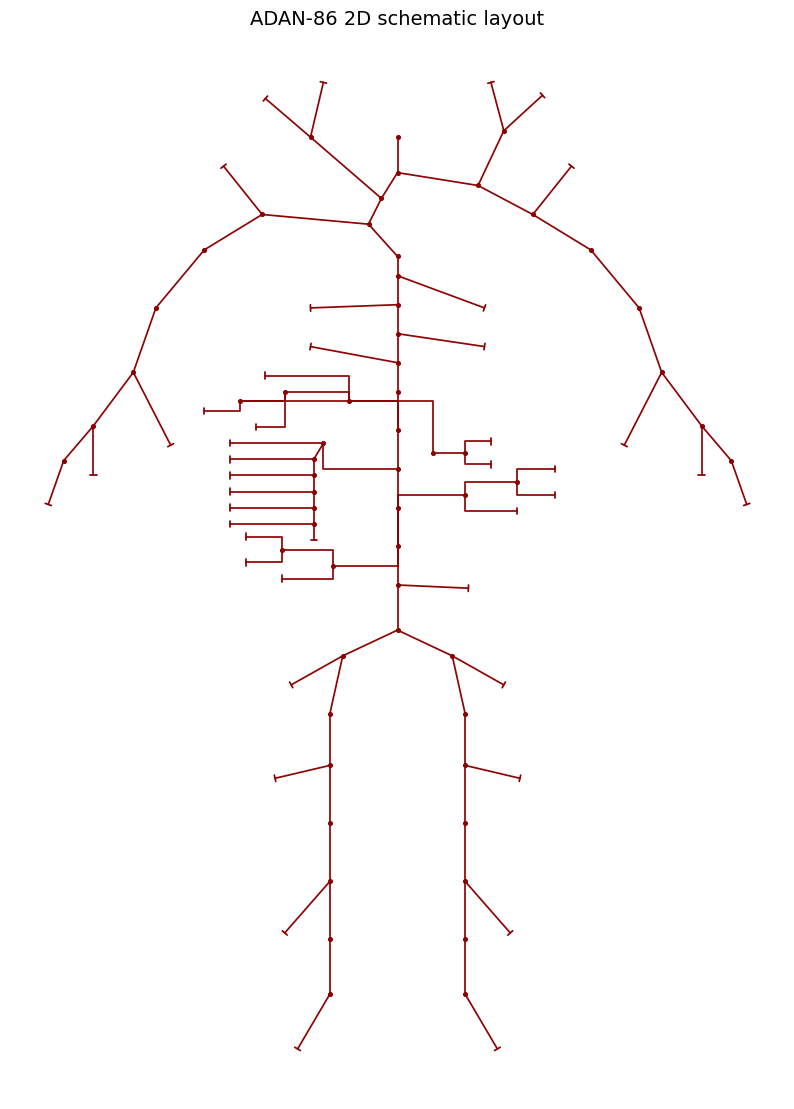

In [7]:
# BUILD AND PREVIEW FINAL LAYOUT
pos2d = build_adan86_pos2d(order)

plot_adan_layout(
    pos2d=pos2d,
    topology_df=topology_df,
    order=order,
    figsize=(10, 16),
    show_labels=False,
    lw=1.25,
    node_size=7,
    cap_len=0.10,
)


## 5. Select and load active candidate

In [8]:
# SELECT AND LOAD ACTIVE CANDIDATE


RESULT, snapshots, t_arr = load_solver_result_robust(
    ACTIVE_CANDIDATE,
    CANDIDATES,
)

t_wave, p_brachial = get_brachial_signal(
    RESULT=RESULT,
    snapshots=snapshots,
    order=order,
)

P_VMIN, P_VMAX = compute_pressure_scale(snapshots)

active_data = {
    "name": ACTIVE_CANDIDATE,
    "RESULT": RESULT,
    "snapshots": snapshots,
    "t": t_arr,
    "t_wave": t_wave,
    "p_brachial": p_brachial,
    "p_vmin": P_VMIN,
    "p_vmax": P_VMAX,
}

print("\nactive_data ready")
print("name:", active_data["name"])
print("snapshots:", len(active_data["snapshots"]))
print("snapshot range:", min(active_data["snapshots"].keys()), "->", max(active_data["snapshots"].keys()))
print("t_wave:", np.min(t_wave), "->", np.max(t_wave), "len:", len(t_wave))
print("p_brachial:", np.nanmin(p_brachial), "->", np.nanmax(p_brachial))
print("pressure scale:", P_VMIN, "->", P_VMAX)


Loaded candidate: candidate_B_bg_v2_8cycles
Path: D:\code\adan_project\results\nb04_bg_v2_final_animation_ready_8cycles.pkl
Loaded type: <class 'dict'>
Found snapshots at: loaded.snapshots
Snapshots: 600
Snapshot time range: 5.0 -> 12.986666666666668
First snapshot shape: (103,)
len(order): 103
Time array found at: t shape: (428280,)
Using saved brachial signal: p_brachial
Using saved time array: t

active_data ready
name: candidate_B_bg_v2_8cycles
snapshots: 600
snapshot range: 5.0 -> 12.986666666666668
t_wave: 1.5949529405645535e-05 -> 7.999992902444513 len: 428280
p_brachial: 80.36358957250573 -> 124.18151080948842
pressure scale: 81.82605743408203 -> 123.84467315673828


## 6. Realtime waveform preparation

This section builds the brachial waveform directly from `snapshots` so the lower monitor panel stays aligned with the ADAN network animation.

Recommended mode: `cycle_loop`, which repeats one selected cardiac cycle across the 20-second video.


In [9]:
# REALTIME LOOP PREPARATION — NO FLAT WAVEFORM GAPS
def get_snapshot_times(snapshots):
    """
    Return sorted snapshot times.

    Args:
        snapshots: Dictionary mapping times to snapshot arrays.

    Returns:
        Sorted snapshot times as a float NumPy array.
    """
    return np.asarray(sorted([float(t) for t in snapshots.keys()]), dtype=float)


def get_nearest_snapshot_time(snapshot_times, t):
    """
    Find the snapshot time closest to a requested time.

    Args:
        snapshot_times: Sorted snapshot time array.
        t: Requested time.

    Returns:
        Nearest snapshot time.
    """
    idx = int(np.argmin(np.abs(snapshot_times - t)))
    return float(snapshot_times[idx])


def build_brachial_trace_from_snapshots(
    snapshots,
    order,
    brachial_vessel="brachial_R34",
):
    """
    Build a brachial pressure trace from snapshot pressure vectors.

    Args:
        snapshots: Dictionary mapping times to pressure vectors.
        order: Vessel order list.
        brachial_vessel: Brachial vessel name to extract.

    Returns:
        (snapshot_times, p_brachial) arrays.

    Raises:
        ValueError: If the brachial vessel is not found.
    """
    if brachial_vessel not in order:
        matches = [v for v in order if "brachial" in v.lower()]
        raise ValueError(
            f"{brachial_vessel} not found in order. "
            f"Brachial-like vessels: {matches}"
        )

    brachial_idx = order.index(brachial_vessel)
    snapshot_times = get_snapshot_times(snapshots)

    p_brachial = np.asarray([
        np.asarray(snapshots[t])[brachial_idx]
        for t in snapshot_times
    ], dtype=float)

    return snapshot_times, p_brachial


def periodic_interp(t_source, y_source, t_query, period):
    """
    Interpolate a signal periodically over repeated cycles.

    Args:
        t_source: Source time array.
        y_source: Source signal array.
        t_query: Query time array.
        period: Loop period.

    Returns:
        Interpolated periodic signal values.

    Raises:
        ValueError: If inputs are invalid.
    """
    t_source = np.asarray(t_source, dtype=float)
    y_source = np.asarray(y_source, dtype=float)
    t_query = np.asarray(t_query, dtype=float)

    if len(t_source) != len(y_source):
        raise ValueError(f"t_source/y_source length mismatch: {len(t_source)} vs {len(y_source)}")

    # Normalize source to start at zero.
    t0 = float(t_source[0])
    ts = t_source - t0

    # Sort and remove duplicate time points.
    sort_idx = np.argsort(ts)
    ts = ts[sort_idx]
    ys = y_source[sort_idx]
    ts, unique_idx = np.unique(ts, return_index=True)
    ys = ys[unique_idx]

    if len(ts) < 2:
        raise ValueError("Need at least 2 unique source time samples for periodic interpolation.")

    period = float(period)
    if period <= 0:
        raise ValueError("period must be > 0")

    # If requested period is longer than available source, shrink to available range.
    # This avoids artificial flat tails.
    available_duration = float(ts[-1] - ts[0])
    if available_duration <= 0:
        raise ValueError("Source time duration must be > 0")

    if available_duration < 0.8 * period:
        print(
            f"WARNING: source duration {available_duration:.3f}s is much shorter than period {period:.3f}s. "
            f"Using available_duration as period."
        )
        period = available_duration

    # Keep only samples inside one period.
    keep = ts <= period
    ts = ts[keep]
    ys = ys[keep]

    # Add endpoint for smooth wrapping back to first value.
    if ts[-1] < period:
        ts_ext = np.concatenate([ts, [period]])
        ys_ext = np.concatenate([ys, [ys[0]]])
    else:
        ts_ext = ts
        ys_ext = ys
        # Force last point to wrap value if it is exactly period.
        if abs(ts_ext[-1] - period) < 1e-9:
            ys_ext[-1] = ys_ext[0]

    tq = np.mod(t_query, period)
    return np.interp(tq, ts_ext, ys_ext)


def prepare_realtime_loop_data(
    data,
    order,
    duration_video_s=20.0,
    fps=30,
    loop_mode="cycle_loop",
    cycle_period_s=1.0,
    cycle_start_offset_s=0.0,
    brachial_vessel="brachial_R34",
):
    """
    Prepare snapshot and waveform data for a looping animation.

    Builds a repeated video timeline, extracts the brachial waveform
    from snapshots, loops either one cardiac cycle or the full recording,
    and computes pressure scale limits for visualization.

    Args:
        data: Result dictionary containing snapshots.
        order: Vessel order list.
        duration_video_s: Output video duration.
        fps: Frames per second.
        loop_mode: Looping mode, either "cycle_loop" or "recording_loop".
        cycle_period_s: Cardiac cycle length for cycle looping.
        cycle_start_offset_s: Offset of selected cycle within snapshots.
        brachial_vessel: Brachial vessel name used for waveform extraction.

    Returns:
        Prepared animation data dictionary.

    Raises:
        ValueError: If snapshot timing or loop configuration is invalid.
    """
    snapshots = data["snapshots"]
    snapshot_times = get_snapshot_times(snapshots)

    physical_start = float(snapshot_times[0])
    physical_end = float(snapshot_times[-1])
    physical_duration = physical_end - physical_start

    if physical_duration <= 0:
        raise ValueError("Snapshot duration must be > 0.")

    n_video_frames = int(round(duration_video_s * fps))
    video_times = np.linspace(0.0, duration_video_s, n_video_frames)

    # Brachial trace directly from snapshots.
    wave_phys_t, wave_p = build_brachial_trace_from_snapshots(
        snapshots=snapshots,
        order=order,
        brachial_vessel=brachial_vessel,
    )

    if loop_mode == "recording_loop":
        loop_period = physical_duration
        source_t0 = physical_start
        source_t1 = physical_end

        # Network and waveform loop through the whole recording.
        physical_times_for_video = physical_start + np.mod(video_times, loop_period)

        t_source = wave_phys_t - physical_start
        p_source = wave_p

        p_video_wave = periodic_interp(
            t_source=t_source,
            y_source=p_source,
            t_query=video_times,
            period=loop_period,
        )

    elif loop_mode == "cycle_loop":
        loop_period = float(cycle_period_s)
        source_t0 = physical_start + float(cycle_start_offset_s)
        source_t1 = source_t0 + loop_period

        if source_t1 > physical_end:
            raise ValueError(
                f"Selected cycle exceeds snapshot range: "
                f"{source_t0:.3f} -> {source_t1:.3f}, snapshots end at {physical_end:.3f}. "
                "Reduce CYCLE_START_OFFSET_S or CYCLE_PERIOD_S."
            )

        # Network repeats the selected physical cycle.
        physical_times_for_video = source_t0 + np.mod(video_times, loop_period)

        # Waveform source = selected cycle only.
        mask = (wave_phys_t >= source_t0) & (wave_phys_t <= source_t1)
        if mask.sum() < 5:
            raise ValueError(
                f"Too few waveform samples in selected cycle: {source_t0:.3f} -> {source_t1:.3f}"
            )

        t_source = wave_phys_t[mask] - source_t0
        p_source = wave_p[mask]

        p_video_wave = periodic_interp(
            t_source=t_source,
            y_source=p_source,
            t_query=video_times,
            period=loop_period,
        )

    else:
        raise ValueError("loop_mode must be 'cycle_loop' or 'recording_loop'")

    # Pressure scale for network colors.
    if "p_vmin" in data and "p_vmax" in data:
        p_vmin = float(data["p_vmin"])
        p_vmax = float(data["p_vmax"])
    else:
        all_p = np.concatenate([
            np.asarray(snapshots[t]).ravel()
            for t in snapshot_times
        ])
        p_vmin = float(np.percentile(all_p, 5))
        p_vmax = float(np.percentile(all_p, 95))

    prepared = dict(data)
    prepared.update({
        "snapshot_times": snapshot_times,
        "snapshot_display_times": snapshot_times - physical_start,
        "physical_start": physical_start,
        "physical_end": physical_end,
        "physical_duration": physical_duration,

        "duration_video_s": float(duration_video_s),
        "fps": int(fps),
        "n_video_frames": int(n_video_frames),
        "video_times": video_times,
        "physical_times_for_video": physical_times_for_video,

        "loop_mode": loop_mode,
        "loop_period": float(loop_period),
        "source_t0": float(source_t0),
        "source_t1": float(source_t1),

        "t_video_wave": video_times,
        "p_video_wave": p_video_wave,

        "p_vmin": p_vmin,
        "p_vmax": p_vmax,
    })

    print("=== Realtime loop prepared ===")
    print("Candidate:", prepared.get("name", "candidate"))
    print("Snapshot physical:", physical_start, "->", physical_end)
    print("Physical duration:", physical_duration)
    print("Loop mode:", loop_mode)
    print("Loop source:", source_t0, "->", source_t1)
    print("Loop period:", loop_period)
    print("Video duration:", duration_video_s)
    print("Expected beats in video:", duration_video_s / loop_period)
    print("Wave pressure:", np.nanmin(p_video_wave), "->", np.nanmax(p_video_wave))
    print("Pressure visual scale:", p_vmin, "->", p_vmax)

    return prepared


## 7. Realtime monitor waveform drawing


In [10]:
def build_pressure_site_traces_from_snapshots(
    snapshots,
    order,
    pressure_sites,
):
    """
    Build pressure traces for multiple anatomical sites from snapshot pressure vectors.

    Args:
        snapshots: Dictionary mapping snapshot time -> pressure vector.
        order: Vessel order list.
        pressure_sites: Dictionary like:
            {
                "central": "ascending_aorta_C0",
                "brachial": "brachial_R34",
                "face_near": "external_carotid_T2_R26",
            }

    Returns:
        snapshot_times: Array of snapshot times.
        site_traces: Dictionary mapping site label -> pressure array [mmHg].

    Raises:
        ValueError: If any requested vessel is missing from order.
    """
    snapshot_times = get_snapshot_times(snapshots)

    site_traces = {}

    for site_label, vessel_name in pressure_sites.items():
        if vessel_name not in order:
            possible_matches = [
                v for v in order
                if site_label.lower() in v.lower()
                or vessel_name.lower() in v.lower()
                or "carotid" in v.lower()
                or "brachial" in v.lower()
                or "aorta" in v.lower()
            ]

            raise ValueError(
                f"Requested vessel '{vessel_name}' for site '{site_label}' "
                f"was not found in order.\n"
                f"Possible relevant vessels:\n{possible_matches}"
            )

        vessel_idx = order.index(vessel_name)

        site_traces[site_label] = np.asarray([
            np.asarray(snapshots[t])[vessel_idx]
            for t in snapshot_times
        ], dtype=float)

    return snapshot_times, site_traces


## 8. Snapshot sanity check

Optional: plot a static pressure snapshot using raw or prepared candidate data.


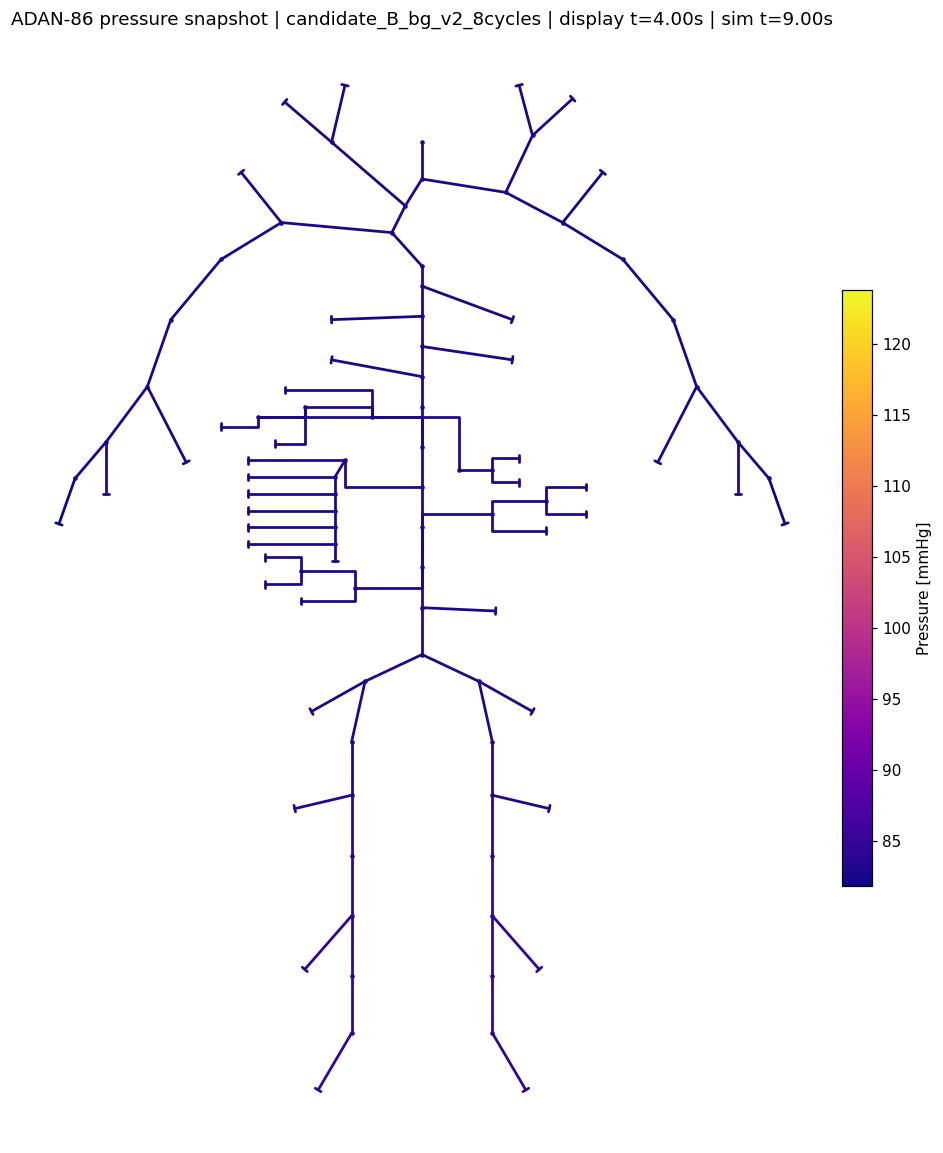

In [11]:
# SNAPSHOT PLOT FROM DATA
def plot_pressure_snapshot_from_data(
    data,
    display_t=None,
    p_vmin=None,
    p_vmax=None,
    figsize=(10, 16),
):
    """
    Plot one ADAN-86 pressure snapshot on the 2D vessel layout.

    Selects the nearest snapshot time, maps vessel pressures to colors,
    draws vessel edges, branch nodes, terminal caps, and adds a pressure
    colorbar.

    Args:
        data: Result or prepared animation dictionary containing snapshots.
        display_t: Display time to plot. If None, uses the middle snapshot.
        p_vmin: Optional lower pressure color limit.
        p_vmax: Optional upper pressure color limit.
        figsize: Matplotlib figure size.

    Returns:
        None.
    """
    snapshots = data["snapshots"]
    snapshot_times = data.get("snapshot_times", get_snapshot_times(snapshots))

    if "snapshot_display_times" in data:
        snapshot_display_times = np.asarray(data["snapshot_display_times"], dtype=float)
    else:
        snapshot_display_times = snapshot_times - float(snapshot_times[0])

    if display_t is None:
        display_t = float(snapshot_display_times[len(snapshot_display_times) // 2])

    idx_near = int(np.argmin(np.abs(snapshot_display_times - display_t)))
    physical_t = float(snapshot_times[idx_near])
    p = np.asarray(snapshots[physical_t])

    if p_vmin is None:
        p_vmin = float(data.get("p_vmin", np.percentile(p, 5)))
    if p_vmax is None:
        p_vmax = float(data.get("p_vmax", np.percentile(p, 95)))

    cmap = plt.get_cmap("plasma")
    norm = mpl.colors.Normalize(vmin=p_vmin, vmax=p_vmax)
    vessel_to_pressure = {v: p[i] for i, v in enumerate(order)}

    parents = set(topology_df["parent"])
    children = set(topology_df["child"])
    terminals = set([v for v in order if (v in children and v not in parents)])
    parent_map = dict(zip(topology_df["child"], topology_df["parent"]))

    fig, ax = plt.subplots(figsize=figsize, dpi=110)

    for _, row in topology_df.iterrows():
        parent, child = row["parent"], row["child"]
        if parent not in pos2d or child not in pos2d:
            continue
        pts = edge_polyline(parent, child, pos2d)
        xs = [pt[0] for pt in pts]
        ys = [pt[1] for pt in pts]
        ax.plot(
            xs,
            ys,
            color=cmap(norm(vessel_to_pressure[child])),
            linewidth=1.8,
            solid_capstyle="round",
            solid_joinstyle="round",
            zorder=1,
        )

    for i, vessel in enumerate(order):
        if vessel in terminals or vessel not in pos2d:
            continue
        x, y = pos2d[vessel]
        ax.scatter(x, y, s=9, color=cmap(norm(p[i])), linewidths=0, zorder=3)

    for vessel in terminals:
        parent = parent_map.get(vessel)
        if parent is None or vessel not in pos2d or parent not in pos2d:
            continue
        draw_terminal_cap(
            ax,
            parent,
            vessel,
            pos2d,
            cap_len=0.10,
            color=cmap(norm(vessel_to_pressure[vessel])),
            lw=1.8,
        )

    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.035, pad=0.02)
    cbar.set_label("Pressure [mmHg]")

    ax.set_title(
        f"ADAN-86 pressure snapshot | {data.get('name', 'candidate')} | "
        f"display t={display_t:.2f}s | sim t={physical_t:.2f}s"
    )
    ax.set_aspect("equal")
    ax.axis("off")
    plt.show()


# Optional sanity check.
plot_pressure_snapshot_from_data(active_data)


## 9. Helpers function 

In [14]:
def diagnose_pressure_sites(
    data,
    pressure_sites=None,
    cycle_period_s=1.0,
):
    """
    Diagnose pressure traces at selected arterial sites.
    
    Extracts pressure waveforms from simulation snapshots and compares
    central, face-near, and brachial signals. The diagnostic checks pressure
    range, pulse pressure, peak timing, and waveform similarity.
    
    This helps determine whether overlapping waveform plots are caused by
    a plotting issue or by genuinely similar pressure traces in the simulation.
    
    Args:
        data: Animation payload containing pressure snapshots and vessel order.
        pressure_sites: Optional dictionary mapping display labels to vessel names.
        cycle_period_s: Cardiac cycle duration [s].
    
    Returns:
        Dictionary containing extracted traces, selected vessels, and diagnostic metrics.
    """
    if pressure_sites is None:
        pressure_sites = {
            "central": "ascending_aorta_C0",
            "brachial": "brachial_R34",
            "face_near": "external_carotid_T2_R26",
        }

    snapshots = data["snapshots"]
    order_local = list(data.get("order", order))

    snapshot_times, site_traces = build_pressure_site_traces_from_snapshots(
        snapshots=snapshots,
        order=order_local,
        pressure_sites=pressure_sites,
    )

    snapshot_times = np.asarray(snapshot_times, dtype=float)

    print("Pressure-site diagnostic")
    print("=" * 72)
    print(f"Number of snapshots: {len(snapshot_times)}")
    print(f"Time range: {snapshot_times[0]:.4f} - {snapshot_times[-1]:.4f} s")
    print(f"Duration: {snapshot_times[-1] - snapshot_times[0]:.4f} s")
    print()

    metrics = {}

    for site_label, trace in site_traces.items():
        trace = np.asarray(trace, dtype=float)

        sbp = float(np.nanmax(trace))
        dbp = float(np.nanmin(trace))
        map_pressure = float(np.nanmean(trace))
        pulse_pressure = sbp - dbp

        peak_idx = int(np.nanargmax(trace))
        peak_time = float(snapshot_times[peak_idx])

        metrics[site_label] = {
            "vessel": pressure_sites[site_label],
            "SBP": sbp,
            "DBP": dbp,
            "MAP": map_pressure,
            "PP": pulse_pressure,
            "peak_time_global": peak_time,
        }

        print(f"{site_label:10s} | {pressure_sites[site_label]}")
        print(f"SBP: {sbp:8.3f} mmHg")
        print(f"DBP: {dbp:8.3f} mmHg")
        print(f"MAP: {map_pressure:8.3f} mmHg")
        print(f"PP: {pulse_pressure:8.3f} mmHg")
        print(f"peak time: {peak_time:8.4f} s")
        print()

    print("Relative peak timing vs central")
    print("-" * 72)

    central_peak_time = metrics["central"]["peak_time_global"]

    for site_label in pressure_sites.keys():
        dt_s = metrics[site_label]["peak_time_global"] - central_peak_time
        dt_ms = dt_s * 1000.0

        metrics[site_label]["delay_vs_central_s"] = float(dt_s)
        metrics[site_label]["delay_vs_central_ms"] = float(dt_ms)

        print(f"{site_label:10s}: {dt_ms:8.3f} ms")

    print()
    print("Trace similarity vs central")
    print("-" * 72)

    central_trace = np.asarray(site_traces["central"], dtype=float)

    for site_label, trace in site_traces.items():
        trace = np.asarray(trace, dtype=float)

        corr = float(np.corrcoef(central_trace, trace)[0, 1])
        max_abs_diff = float(np.nanmax(np.abs(trace - central_trace)))
        mean_abs_diff = float(np.nanmean(np.abs(trace - central_trace)))

        metrics[site_label]["corr_vs_central"] = corr
        metrics[site_label]["max_abs_diff_vs_central"] = max_abs_diff
        metrics[site_label]["mean_abs_diff_vs_central"] = mean_abs_diff

        print(f"{site_label:10s}")
        print(f"  correlation:          {corr:8.5f}")
        print(f"  max abs difference:   {max_abs_diff:8.3f} mmHg")
        print(f"  mean abs difference:  {mean_abs_diff:8.3f} mmHg")
        print()

    return {
        "snapshot_times": snapshot_times,
        "site_traces": site_traces,
        "pressure_sites": pressure_sites,
        "metrics": metrics,
    }

In [15]:
diag = diagnose_pressure_sites(
    data=active_data,
    pressure_sites={
        "central": "ascending_aorta_C0",
        "brachial": "brachial_R34",
        "face_near": "external_carotid_T2_R26",
    },
    cycle_period_s=1.0,
)

Pressure-site diagnostic
Number of snapshots: 600
Time range: 5.0000 - 12.9867 s
Duration: 7.9867 s

central    | ascending_aorta_C0
SBP:  119.853 mmHg
DBP:   82.739 mmHg
MAP:  101.480 mmHg
PP:   37.114 mmHg
peak time:   5.3333 s

brachial   | brachial_R34
SBP:  124.181 mmHg
DBP:   80.404 mmHg
MAP:  101.127 mmHg
PP:   43.777 mmHg
peak time:   5.3333 s

face_near  | external_carotid_T2_R26
SBP:  121.273 mmHg
DBP:   81.456 mmHg
MAP:  101.442 mmHg
PP:   39.816 mmHg
peak time:   5.3200 s

Relative peak timing vs central
------------------------------------------------------------------------
central   :    0.000 ms
brachial  :    0.000 ms
face_near :  -13.333 ms

Trace similarity vs central
------------------------------------------------------------------------
central   
  correlation:           1.00000
  max abs difference:      0.000 mmHg
  mean abs difference:     0.000 mmHg

brachial  
  correlation:           0.98790
  max abs difference:      5.896 mmHg
  mean abs difference:     1

In [16]:
def estimate_site_delays_by_cross_correlation(
    diag,
    reference_site="central",
):
    """
    Estimate relative timing differences between pressure waveforms using
    cross-correlation.
    
    Unlike simple peak detection, cross-correlation compares the entire
    waveform shape and provides a more robust estimate of pulse arrival
    delay between arterial sites.
    
    Positive delay:
        waveform occurs later than the reference site.
    
    Negative delay:
        waveform occurs earlier than the reference site.
    
    Args:
        diag: Output from diagnose_pressure_sites().
        reference_site: Site used as the timing reference.
    
    Returns:
        Dictionary containing estimated delays, lag values, and
        cross-correlation statistics for each site.
    """
    snapshot_times = np.asarray(diag["snapshot_times"], dtype=float)
    site_traces = diag["site_traces"]

    dt = float(np.median(np.diff(snapshot_times)))

    ref = np.asarray(site_traces[reference_site], dtype=float)
    ref_centered = ref - np.mean(ref)

    print("Cross-correlation delay estimate")
    print("=" * 72)
    print(f"Reference site: {reference_site}")
    print(f"Snapshot dt:    {dt * 1000:.3f} ms")
    print()

    results = {}

    for site_label, trace in site_traces.items():
        trace = np.asarray(trace, dtype=float)
        trace_centered = trace - np.mean(trace)

        corr = np.correlate(
            trace_centered,
            ref_centered,
            mode="full",
        )

        lags = np.arange(
            -len(ref_centered) + 1,
            len(ref_centered),
        )

        best_lag = int(lags[np.argmax(corr)])
        delay_s = best_lag * dt
        delay_ms = delay_s * 1000.0

        results[site_label] = {
            "best_lag_samples": best_lag,
            "delay_s": delay_s,
            "delay_ms": delay_ms,
            "max_corr_raw": float(np.max(corr)),
        }

        print(f"{site_label:10s}")
        print(f"  lag samples: {best_lag:6d}")
        print(f"  delay:       {delay_ms:8.3f} ms")
        print()

    return results

In [17]:
delay_diag = estimate_site_delays_by_cross_correlation(diag)

Cross-correlation delay estimate
Reference site: central
Snapshot dt:    13.333 ms

central   
  lag samples:      0
  delay:          0.000 ms

brachial  
  lag samples:      0
  delay:          0.000 ms

face_near 
  lag samples:      0
  delay:          0.000 ms



In [18]:
def diagnose_model_pwv(
    data=None,
    vessel_order=None,
    c0_values=None,
    dx_values=None,
):
    """
    Diagnose model-predicted pulse wave velocity for key arterial paths.
    
    Uses the solver wave-speed vector (`c0`) to summarize local PWV values
    and, when vessel lengths are available, estimate approximate transit time
    along selected paths such as the aorta, right brachial path, and carotid/
    face-near path.
    
    This diagnostic helps explain whether pressure-wave delays should be
    visually detectable in the animation or whether they are too small relative
    to the video frame rate and snapshot spacing.
    
    Args:
        data: Optional animation/result payload containing vessel order.
        vessel_order: Optional explicit vessel order list.
        c0_values: Local wave-speed values for each vessel [m/s].
        dx_values: Optional vessel lengths used to estimate transit delay [m].
    
    Returns:
        Dictionary with PWV ranges and approximate path delays for each group.
    """

    # Resolve vessel order
    if vessel_order is not None:
        order_local = list(vessel_order)
    elif data is not None and "order" in data:
        order_local = list(data["order"])
    elif "order" in globals():
        order_local = list(order)
    else:
        raise ValueError(
            "Could not find vessel order. Provide vessel_order, data['order'], or global order."
        )

    # Resolve c0 values
    if c0_values is not None:
        c0_local = np.asarray(c0_values, dtype=float)
    elif "c0v" in globals():
        c0_local = np.asarray(c0v, dtype=float)
    else:
        raise ValueError(
            "Could not find wave-speed vector. Provide c0_values or make sure global c0v exists."
        )

    if len(c0_local) != len(order_local):
        raise ValueError(
            f"Length mismatch: len(c0_values)={len(c0_local)}, len(order)={len(order_local)}"
        )

    # Resolve optional vessel lengths
    if dx_values is not None:
        dx_local = np.asarray(dx_values, dtype=float)
    elif "dxv" in globals():
        dx_local = np.asarray(dxv, dtype=float)
    else:
        dx_local = None

    if dx_local is not None and len(dx_local) != len(order_local):
        raise ValueError(
            f"Length mismatch: len(dx_values)={len(dx_local)}, len(order)={len(order_local)}"
        )

    # Vessel groups
    groups = {
        "ascending_aorta": ["ascending_aorta"],
        "all_aorta": ["aorta", "aortic_arch"],
        "right_brachial_path": [
            "brachiocephalic",
            "subclavian_R",
            "axillary_R",
            "brachial_R",
        ],
        "brachial_only": ["brachial_R34"],
        "face_near_path": [
            "brachiocephalic",
            "common_carotid_R",
            "external_carotid_T2_R26",
        ],
    }

    results = {}

    print("Model PWV diagnostic")
    print("=" * 72)

    for group_name, keywords in groups.items():
        idxs = []

        for i, vessel_name in enumerate(order_local):
            for kw in keywords:
                if kw.lower() in vessel_name.lower():
                    idxs.append(i)
                    break

        idxs = sorted(set(idxs))

        if len(idxs) == 0:
            print(f"{group_name}: no vessels found")
            print()
            continue

        speeds = c0_local[idxs]

        group_result = {
            "vessels": [order_local[i] for i in idxs],
            "idxs": idxs,
            "c0_min_m_s": float(np.min(speeds)),
            "c0_mean_m_s": float(np.mean(speeds)),
            "c0_max_m_s": float(np.max(speeds)),
        }

        print(f"{group_name}")
        print("-" * 72)

        for i in idxs:
            vessel = order_local[i]
            c = c0_local[i]

            if dx_local is not None:
                L = dx_local[i]
                local_delay_ms = 1000.0 * L / c if c > 0 else np.nan
                print(f"  {vessel:35s} c0={c:7.3f} m/s | L={L:7.4f} m | L/c={local_delay_ms:7.3f} ms")
            else:
                print(f"  {vessel:35s} c0={c:7.3f} m/s")

        print()
        print(f"  PWV min:   {group_result['c0_min_m_s']:.3f} m/s")
        print(f"  PWV mean:  {group_result['c0_mean_m_s']:.3f} m/s")
        print(f"  PWV max:   {group_result['c0_max_m_s']:.3f} m/s")

        if dx_local is not None:
            total_length = float(np.sum(dx_local[idxs]))
            approx_delay_ms = 1000.0 * float(np.sum(dx_local[idxs] / c0_local[idxs]))

            group_result["total_length_m"] = total_length
            group_result["approx_transit_delay_ms"] = approx_delay_ms

            print(f"  total length:          {total_length:.4f} m")
            print(f"  approx transit delay:  {approx_delay_ms:.3f} ms")

        print()
        results[group_name] = group_result

    return results

In [19]:
pwv_diag = diagnose_model_pwv(
    data=active_data,
    c0_values=adan["c0v"],
    dx_values=adan["Lv"],
)

Model PWV diagnostic
ascending_aorta
------------------------------------------------------------------------
  ascending_aorta_C0                  c0=  5.311 m/s | L= 0.0600 m | L/c= 11.298 ms

  PWV min:   5.311 m/s
  PWV mean:  5.311 m/s
  PWV max:   5.311 m/s
  total length:          0.0600 m
  approx transit delay:  11.298 ms

all_aorta
------------------------------------------------------------------------
  ascending_aorta_C0                  c0=  5.311 m/s | L= 0.0600 m | L/c= 11.298 ms
  aortic_arch_C2                      c0=  5.367 m/s | L= 0.0145 m | L/c=  2.697 ms
  aortic_arch_C46                     c0=  5.385 m/s | L= 0.0096 m | L/c=  1.784 ms
  aortic_arch_C64                     c0=  5.397 m/s | L= 0.0070 m | L/c=  1.293 ms
  aortic_arch_C94                     c0=  5.428 m/s | L= 0.0432 m | L/c=  7.961 ms
  thoracic_aorta_C96                  c0=  5.477 m/s | L= 0.0099 m | L/c=  1.807 ms
  thoracic_aorta_C100                 c0=  5.485 m/s | L= 0.0079 m | L/c=  1.43

In [20]:
def plot_mean_pressure_vs_distance_from_heart(
    data,
    adan,
    root_vessel="ascending_aorta_C0",
    n_bins=18,
    show_scatter=True,
    figsize=(10, 5),
):
    """
    Plot mean arterial pressure as a function of distance from the heart.
    
    For each artery in the ADAN network:
        - compute mean pressure across recorded snapshots
        - compute cumulative distance from the ascending aorta
        - group vessels into distance bins
        - plot the average pressure trend
    
    This provides a simplified view of how pressure changes from
    central arteries toward the peripheral circulation.
    
    Args:
        data: Animation payload containing pressure snapshots and vessel order.
        adan: Parsed ADAN model containing vessel lengths and topology.
        root_vessel: Vessel treated as the heart-side reference.
        n_bins: Number of distance bins used for averaging.
        show_scatter: Show individual vessel measurements.
        figsize: Matplotlib figure size.
    
    Returns:
        Dictionary containing vessel-level and binned pressure statistics.
    """

    # Extract required data

    snapshots = data["snapshots"]
    order_local = list(data.get("order", order))

    Lv = np.asarray(adan["Lv"], dtype=float)
    parent_idx = np.asarray(adan["parent_idx"], dtype=int)

    if len(Lv) != len(order_local):
        raise ValueError(
            f"len(adan['Lv'])={len(Lv)} but len(order)={len(order_local)}"
        )

    if len(parent_idx) != len(order_local):
        raise ValueError(
            f"len(adan['parent_idx'])={len(parent_idx)} but len(order)={len(order_local)}"
        )

    if root_vessel not in order_local:
        raise ValueError(f"root_vessel '{root_vessel}' not found in order.")

    root_idx = order_local.index(root_vessel)

    # Compute mean pressure per vessel
    snapshot_times = np.array(sorted(snapshots.keys()), dtype=float)

    pressure_matrix = np.vstack([
        np.asarray(snapshots[t], dtype=float)
        for t in snapshot_times
    ])

    # shape: [n_snapshots, n_vessels]
    mean_pressure_per_vessel = np.nanmean(pressure_matrix, axis=0)

    # Compute cumulative distance from heart
    distance_from_root = np.full(len(order_local), np.nan, dtype=float)

    def compute_distance_to_root(i):
        """
        Recursively compute distance from root to vessel i.

        Distance convention:
            root vessel starts at 0
            child distance = parent distance + parent vessel length

        This means each vessel is positioned approximately at its proximal
        location along the arterial tree.
        """
        if i == root_idx:
            return 0.0

        if np.isfinite(distance_from_root[i]):
            return distance_from_root[i]

        p = int(parent_idx[i])

        if p < 0:
            return np.nan

        parent_distance = compute_distance_to_root(p)

        if not np.isfinite(parent_distance):
            return np.nan

        distance_from_root[i] = parent_distance + Lv[p]
        return distance_from_root[i]

    for i in range(len(order_local)):
        distance_from_root[i] = compute_distance_to_root(i)

    valid = (
        np.isfinite(distance_from_root)
        & np.isfinite(mean_pressure_per_vessel)
    )

    distances = distance_from_root[valid]
    mean_pressures = mean_pressure_per_vessel[valid]
    valid_vessels = np.array(order_local, dtype=object)[valid]

    # Bin by distance to create one clean curve
    bin_edges = np.linspace(
        float(np.min(distances)),
        float(np.max(distances)),
        n_bins + 1,
    )

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    binned_mean_pressure = np.full(n_bins, np.nan, dtype=float)
    binned_std_pressure = np.full(n_bins, np.nan, dtype=float)
    binned_counts = np.zeros(n_bins, dtype=int)

    for b in range(n_bins):
        if b == n_bins - 1:
            mask = (distances >= bin_edges[b]) & (distances <= bin_edges[b + 1])
        else:
            mask = (distances >= bin_edges[b]) & (distances < bin_edges[b + 1])

        if np.any(mask):
            binned_mean_pressure[b] = float(np.mean(mean_pressures[mask]))
            binned_std_pressure[b] = float(np.std(mean_pressures[mask]))
            binned_counts[b] = int(np.sum(mask))

    valid_bins = np.isfinite(binned_mean_pressure)

    # Plot
    fig, ax = plt.subplots(figsize=figsize)

    if show_scatter:
        ax.scatter(
            distances,
            mean_pressures,
            s=25,
            alpha=0.35,
            label="individual arteries",
        )

    ax.plot(
        bin_centers[valid_bins],
        binned_mean_pressure[valid_bins],
        linewidth=2.5,
        marker="o",
        label="binned mean pressure",
    )

    ax.set_xlabel("Cumulative arterial distance from heart [m]")
    ax.set_ylabel("Mean pressure [mmHg]")
    ax.set_title("Mean arterial pressure vs distance from heart")
    ax.grid(True, alpha=0.3)
    ax.legend()

    # Helpful labels at both ends
    ax.text(
        bin_centers[valid_bins][0],
        binned_mean_pressure[valid_bins][0],
        "  heart / central",
        va="bottom",
        fontsize=9,
    )

    ax.text(
        bin_centers[valid_bins][-1],
        binned_mean_pressure[valid_bins][-1],
        "  peripheral arteries",
        va="bottom",
        fontsize=9,
    )

    plt.tight_layout()

    # Print short summary

    print("Mean pressure vs distance diagnostic")
    print("=" * 72)
    print(f"Number of vessels used: {len(distances)}")
    print(f"Distance range:         {np.min(distances):.3f} - {np.max(distances):.3f} m")
    print(f"Mean pressure range:    {np.min(mean_pressures):.3f} - {np.max(mean_pressures):.3f} mmHg")
    print()
    print("Binned curve:")
    for x, y, c in zip(bin_centers[valid_bins], binned_mean_pressure[valid_bins], binned_counts[valid_bins]):
        print(f"  distance={x:.3f} m | mean pressure={y:.3f} mmHg | n={c}")

    return {
        "fig": fig,
        "ax": ax,
        "vessels": valid_vessels,
        "distances": distances,
        "mean_pressures": mean_pressures,
        "bin_centers": bin_centers,
        "binned_mean_pressure": binned_mean_pressure,
        "binned_std_pressure": binned_std_pressure,
        "binned_counts": binned_counts,
    }

Mean pressure vs distance diagnostic
Number of vessels used: 103
Distance range:         0.000 - 1.131 m
Mean pressure range:    98.713 - 101.488 mmHg

Binned curve:
  distance=0.031 m | mean pressure=101.472 mmHg | n=2
  distance=0.094 m | mean pressure=101.476 mmHg | n=8
  distance=0.157 m | mean pressure=101.338 mmHg | n=15
  distance=0.220 m | mean pressure=101.383 mmHg | n=4
  distance=0.283 m | mean pressure=101.379 mmHg | n=7
  distance=0.346 m | mean pressure=101.415 mmHg | n=20
  distance=0.408 m | mean pressure=101.371 mmHg | n=11
  distance=0.471 m | mean pressure=101.376 mmHg | n=10
  distance=0.534 m | mean pressure=100.594 mmHg | n=8
  distance=0.597 m | mean pressure=100.065 mmHg | n=4
  distance=0.660 m | mean pressure=101.293 mmHg | n=4
  distance=0.974 m | mean pressure=101.303 mmHg | n=2
  distance=1.100 m | mean pressure=100.715 mmHg | n=8


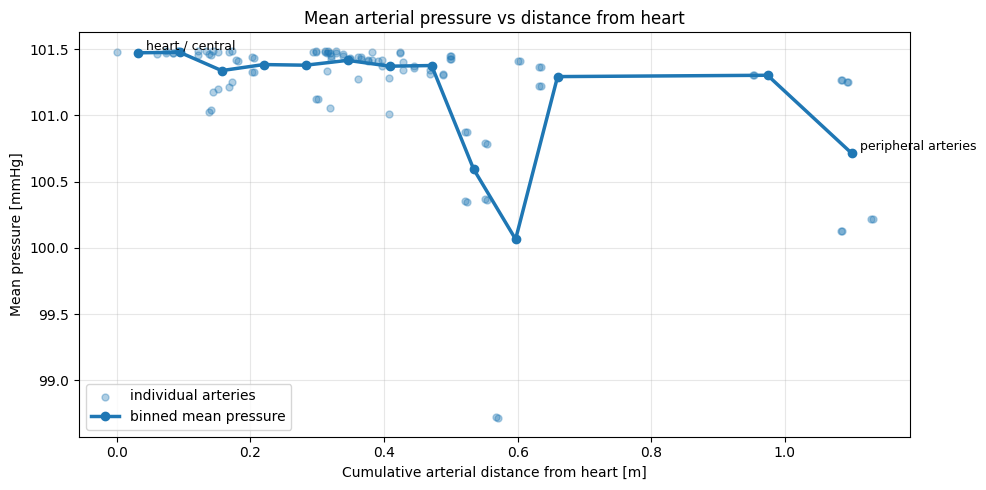

In [21]:
mean_pressure_distance = plot_mean_pressure_vs_distance_from_heart(
    data=active_data,
    adan=adan,
    root_vessel="ascending_aorta_C0",
    n_bins=18,
    show_scatter=True,
)

In [22]:
def build_mean_pressure_distance_curve(
    data,
    adan,
    root_vessel="ascending_aorta_C0",
    n_bins=18,
    pressure_mode="drop_from_root",
):
    """
    Build data for the mean-pressure-versus-distance animation panel.
    
    For each artery in the ADAN network:
        - compute mean pressure across recorded snapshots
        - compute cumulative distance from the ascending aorta
        - optionally express pressure relative to the root vessel
        - group vessels into distance bins
        - generate a smooth distance-pressure trend
    
    This converts the complex branching arterial tree into a single
    heart-to-periphery curve suitable for visualization and animation.
    
    Args:
        data: Animation payload containing pressure snapshots and vessel order.
        adan: Parsed ADAN model containing vessel lengths and topology.
        root_vessel: Vessel treated as the heart-side reference.
        n_bins: Number of distance bins used for averaging.
        pressure_mode:
            "absolute" -> mean pressure [mmHg]
            "drop_from_root" -> pressure difference relative to root vessel.
    
    Returns:
        Dictionary containing vessel-level and binned pressure-distance data
        used by the animation panel.
    """
    snapshots = data["snapshots"]
    order_local = list(data.get("order", order))

    Lv = np.asarray(adan["Lv"], dtype=float)
    parent_idx = np.asarray(adan["parent_idx"], dtype=int)

    if len(Lv) != len(order_local):
        raise ValueError(
            f"len(adan['Lv'])={len(Lv)} but len(order)={len(order_local)}"
        )

    if len(parent_idx) != len(order_local):
        raise ValueError(
            f"len(adan['parent_idx'])={len(parent_idx)} but len(order)={len(order_local)}"
        )

    if root_vessel not in order_local:
        raise ValueError(f"root_vessel '{root_vessel}' not found in order.")

    root_idx = order_local.index(root_vessel)

    # Mean pressure per vessel
    snapshot_times = np.array(sorted(snapshots.keys()), dtype=float)

    pressure_matrix = np.vstack([
        np.asarray(snapshots[t], dtype=float)
        for t in snapshot_times
    ])

    mean_pressure_per_vessel = np.nanmean(pressure_matrix, axis=0)
    root_mean_pressure = float(mean_pressure_per_vessel[root_idx])

    # Distance from root through arterial tree
    distance_from_root = np.full(len(order_local), np.nan, dtype=float)

    def compute_distance_to_root(i):
        if i == root_idx:
            return 0.0

        if np.isfinite(distance_from_root[i]):
            return distance_from_root[i]

        p = int(parent_idx[i])

        if p < 0:
            return np.nan

        parent_distance = compute_distance_to_root(p)

        if not np.isfinite(parent_distance):
            return np.nan

        distance_from_root[i] = parent_distance + Lv[p]
        return distance_from_root[i]

    for i in range(len(order_local)):
        distance_from_root[i] = compute_distance_to_root(i)

    valid = (
        np.isfinite(distance_from_root)
        & np.isfinite(mean_pressure_per_vessel)
    )

    distances = distance_from_root[valid]
    mean_pressures = mean_pressure_per_vessel[valid]
    valid_vessels = np.array(order_local, dtype=object)[valid]

    if pressure_mode == "absolute":
        y_values = mean_pressures
        y_label = "Mean pressure [mmHg]"
    elif pressure_mode == "drop_from_root":
        y_values = mean_pressures - root_mean_pressure
        y_label = "Mean pressure change from heart [mmHg]"
    else:
        raise ValueError(
            "pressure_mode must be either 'absolute' or 'drop_from_root'"
        )

    # Bin vessels by distance to create one clean curve
    bin_edges = np.linspace(
        float(np.min(distances)),
        float(np.max(distances)),
        n_bins + 1,
    )

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    binned_y = np.full(n_bins, np.nan, dtype=float)
    binned_std = np.full(n_bins, np.nan, dtype=float)
    binned_counts = np.zeros(n_bins, dtype=int)

    for b in range(n_bins):
        if b == n_bins - 1:
            mask = (distances >= bin_edges[b]) & (distances <= bin_edges[b + 1])
        else:
            mask = (distances >= bin_edges[b]) & (distances < bin_edges[b + 1])

        if np.any(mask):
            binned_y[b] = float(np.mean(y_values[mask]))
            binned_std[b] = float(np.std(y_values[mask]))
            binned_counts[b] = int(np.sum(mask))

    valid_bins = np.isfinite(binned_y)

    print("Mean-pressure distance curve prepared")
    print("=" * 72)
    print(f"Root vessel: {root_vessel}")
    print(f"Root mean pressure: {root_mean_pressure:.3f} mmHg")
    print(f"Distance range: {np.min(distances):.3f} - {np.max(distances):.3f} m")
    print(f"Pressure mode: {pressure_mode}")
    print(f"Valid bins: {np.sum(valid_bins)} / {n_bins}")

    return {
        "root_vessel": root_vessel,
        "root_mean_pressure": root_mean_pressure,
        "pressure_mode": pressure_mode,
        "y_label": y_label,

        "vessels": valid_vessels,
        "distances": distances,
        "mean_pressures": mean_pressures,
        "y_values": y_values,

        "bin_centers": bin_centers,
        "binned_y": binned_y,
        "binned_std": binned_std,
        "binned_counts": binned_counts,
        "valid_bins": valid_bins,
    }

In [23]:
map_distance_curve = build_mean_pressure_distance_curve(
    data=active_data,
    adan=adan,
    root_vessel="ascending_aorta_C0",
    n_bins=18,
    pressure_mode="drop_from_root",
)

Mean-pressure distance curve prepared
Root vessel: ascending_aorta_C0
Root mean pressure: 101.480 mmHg
Distance range: 0.000 - 1.131 m
Pressure mode: drop_from_root
Valid bins: 13 / 18


## 10. Complete animation function

This is the main animation builder. It loops either a selected cycle or the whole recording and draws a continuous monitor trace across the full 20-second video.


In [24]:
def make_adan86_animation(
    data,
    duration_video_s=20.0,
    fps=30,
    dpi=100,
    figsize=(19.2, 10.8),
    loop_mode="cycle_loop",
    cycle_period_s=1.0,
    cycle_start_offset_s=0.0,
    monitor_style=False,
    network_lw=1.8,
    node_size=12,
    cap_len=0.10,
    repeat=False,
    use_pressure_linewidth=True,
    pressure_lw_min=0.5,
    pressure_lw_max=10.0,
    pressure_delta_ref_mmHg=100.0,
    pressure_sites=None,
    waveform_window_s=2.0,
    waveform_pressure_ylim=(70, 130),
    adan=None,
    show_map_distance_panel=True,
    map_distance_n_bins=18,
):
    """
    Create an animated visualization of pressure-wave propagation in the
    ADAN-86 arterial network.
    
    The animation combines three complementary views:
    
        1. Arterial topology
           - vessel color represents local pressure
           - vessel thickness scales with pressure magnitude
           - pressure is updated frame-by-frame using recorded snapshots
    
        2. Pressure waveform panel
           - displays central, carotid, and brachial pressure traces
           - includes a moving time cursor
           - continuously updates systolic, diastolic, pulse pressure,
             and mean pressure values
    
        3. Mean-pressure distance panel
           - shows how mean arterial pressure changes with distance
             from the heart
           - highlights major arteries along the arterial tree
           - displays the current position and pressure level
             during animation playback
    
    The animation is intended as an educational and exploratory
    visualization of pressure-wave propagation in a 1D arterial model,
    rather than a physiological validation tool.
    
    Args:
        data: Animation payload containing pressure snapshots and waveform data.
        duration_video_s: Output video duration [s].
        fps: Animation frame rate.
        dpi: Figure export resolution.
        figsize: Figure size in inches.
        loop_mode: Strategy used to replay recorded cardiac cycles.
        cycle_period_s: Cardiac cycle duration [s].
        cycle_start_offset_s: Cycle offset applied during looping.
        monitor_style: Legacy display option.
        network_lw: Default vessel linewidth.
        node_size: Vessel-node marker size.
        cap_len: Terminal vessel cap length.
        repeat: Whether the animation repeats.
        use_pressure_linewidth: Scale vessel width using pressure.
        pressure_lw_min: Minimum vessel linewidth.
        pressure_lw_max: Maximum vessel linewidth.
        pressure_delta_ref_mmHg: Pressure range used for linewidth scaling.
        pressure_sites: Dictionary of monitored anatomical sites.
        waveform_window_s: Visible waveform history window [s].
        waveform_pressure_ylim: Pressure-axis limits [mmHg].
        adan: Parsed ADAN model structure.
        show_map_distance_panel: Enable mean-pressure distance panel.
        map_distance_n_bins: Number of distance bins used for averaging.
    
    Returns:
        Dictionary containing:
            - anim: Matplotlib animation object
            - fig: Figure object
            - prepared: Prepared animation data
            - map_distance_curve: Distance-pressure curve data
            - update: Frame update callback
    """

    prepared = prepare_realtime_loop_data(
        data=data,
        order=order,
        duration_video_s=duration_video_s,
        fps=fps,
        loop_mode=loop_mode,
        cycle_period_s=cycle_period_s,
        cycle_start_offset_s=cycle_start_offset_s,
        brachial_vessel="brachial_R34",
    )

    snapshots = prepared["snapshots"]
    snapshot_times = prepared["snapshot_times"]
    video_times = prepared["video_times"]
    physical_times_for_video = prepared["physical_times_for_video"]
    p_vmin = prepared["p_vmin"]
    p_vmax = prepared["p_vmax"]
    animation_order = list(data.get("order", order))

    if pressure_sites is None:
        pressure_sites = {
            "central": "ascending_aorta_C0",
            "face_near": "external_carotid_T2_R26",
            "brachial": "brachial_R34",
        }

    site_order = ["central", "face_near", "brachial"]

    site_colors = {
        "central": "red",
        "face_near": "blue",
        "brachial": "limegreen",
    }

    legend_names = {
        "central": "Ascending Aorta",
        "face_near": "External Carotid",
        "brachial": "Right Brachial",
    }

    table_names = legend_names.copy()

    site_snapshot_times, site_traces = build_pressure_site_traces_from_snapshots(
        snapshots=snapshots,
        order=animation_order,
        pressure_sites=pressure_sites,
    )

    pressure_site_video_traces = {
        site_label: np.interp(physical_times_for_video, site_snapshot_times, p_trace)
        for site_label, p_trace in site_traces.items()
    }

    prepared["pressure_sites"] = pressure_sites
    prepared["pressure_site_video_traces"] = pressure_site_video_traces

    map_distance_curve = None
    if show_map_distance_panel:
        if adan is None:
            raise ValueError("show_map_distance_panel=True requires adan=adan")

        map_distance_curve = build_mean_pressure_distance_curve(
            data=data,
            adan=adan,
            root_vessel="ascending_aorta_C0",
            n_bins=map_distance_n_bins,
            pressure_mode="drop_from_root",
        )

    def pressure_to_linewidth(p_values):
        p_values = np.asarray(p_values, dtype=float)
        delta_p = np.clip(p_values - p_vmin, 0.0, pressure_delta_ref_mmHg)
        alpha = delta_p / pressure_delta_ref_mmHg
        return pressure_lw_min + alpha * (pressure_lw_max - pressure_lw_min)

    vessel_to_idx = {v: i for i, v in enumerate(animation_order)}

    segments = []
    edge_vessel_idx = []

    for _, row in topology_df.iterrows():
        parent = row["parent"]
        child = row["child"]

        if parent not in pos2d or child not in pos2d:
            continue
        if child not in vessel_to_idx:
            continue

        segments.append(edge_polyline(parent, child, pos2d))
        edge_vessel_idx.append(vessel_to_idx[child])

    edge_vessel_idx = np.asarray(edge_vessel_idx, dtype=int)

    visible_order = [v for v in animation_order if v in pos2d]

    parents = set(topology_df["parent"])
    children = set(topology_df["child"])
    terminals = set([v for v in visible_order if (v in children and v not in parents)])
    parent_map = dict(zip(topology_df["child"], topology_df["parent"]))

    nonterminal_idx = np.asarray([
        vessel_to_idx[v]
        for v in visible_order
        if v not in terminals
    ], dtype=int)

    nonterminal_xy = np.asarray([
        pos2d[v]
        for v in visible_order
        if v not in terminals
    ])

    nonterminal_x = nonterminal_xy[:, 0]
    nonterminal_y = nonterminal_xy[:, 1]

    terminal_segments = []
    terminal_vessel_idx = []

    for vessel in terminals:
        parent = parent_map.get(vessel)

        if parent is None or parent not in pos2d:
            continue
        if vessel not in vessel_to_idx:
            continue

        pts = edge_polyline(parent, vessel, pos2d)
        (x1, y1), (x2, y2) = pts[-2], pts[-1]

        dx = x2 - x1
        dy = y2 - y1
        L = np.hypot(dx, dy)

        if L < 1e-12:
            continue

        px = -dy / L
        py = dx / L

        hx = 0.5 * cap_len * px
        hy = 0.5 * cap_len * py

        terminal_segments.append([(x2 - hx, y2 - hy), (x2 + hx, y2 + hy)])
        terminal_vessel_idx.append(vessel_to_idx[vessel])

    terminal_vessel_idx = np.asarray(terminal_vessel_idx, dtype=int)

    fig = plt.figure(figsize=figsize, dpi=dpi)
    fig.patch.set_facecolor("white")

    ax_net = fig.add_axes([0.035, 0.385, 0.875, 0.57])
    ax_cbar = fig.add_axes([0.925, 0.49, 0.014, 0.37])

    ax_wave = fig.add_axes([0.085, 0.145, 0.42, 0.205])
    ax_table = fig.add_axes([0.085, 0.035, 0.42, 0.085])

    ax_map = None
    if show_map_distance_panel:
        ax_map = fig.add_axes([0.575, 0.075, 0.37, 0.275])

    cmap = plt.get_cmap("plasma")
    norm = mpl.colors.Normalize(vmin=p_vmin, vmax=p_vmax)

    initial_video_t = float(video_times[0])
    initial_physical_t = float(physical_times_for_video[0])
    initial_snap_t = get_nearest_snapshot_time(snapshot_times, initial_physical_t)
    initial_p = np.asarray(snapshots[initial_snap_t])

    if use_pressure_linewidth:
        initial_network_lw = pressure_to_linewidth(initial_p[edge_vessel_idx])
        initial_terminal_lw = pressure_to_linewidth(initial_p[terminal_vessel_idx])
    else:
        initial_network_lw = network_lw
        initial_terminal_lw = network_lw

    # ADAN topology panel
    lc = LineCollection(
        segments,
        cmap=cmap,
        norm=norm,
        linewidths=initial_network_lw,
        capstyle="round",
        joinstyle="round",
        zorder=1,
    )
    lc.set_array(initial_p[edge_vessel_idx])
    ax_net.add_collection(lc)

    terminal_lc = LineCollection(
        terminal_segments,
        cmap=cmap,
        norm=norm,
        linewidths=initial_terminal_lw,
        capstyle="round",
        zorder=4,
    )
    terminal_lc.set_array(initial_p[terminal_vessel_idx])
    ax_net.add_collection(terminal_lc)

    node_scatter = ax_net.scatter(
        nonterminal_x,
        nonterminal_y,
        c=initial_p[nonterminal_idx],
        cmap=cmap,
        norm=norm,
        s=node_size,
        linewidths=0,
        zorder=3,
    )

    all_xy = np.asarray([pos2d[v] for v in visible_order])
    x_min, x_max = float(np.min(all_xy[:, 0])), float(np.max(all_xy[:, 0]))
    y_min, y_max = float(np.min(all_xy[:, 1])), float(np.max(all_xy[:, 1]))

    x_pad = 0.03 * (x_max - x_min)
    y_pad = 0.03 * (y_max - y_min)

    ax_net.set_xlim(x_min - x_pad, x_max + x_pad)
    ax_net.set_ylim(y_min - y_pad, y_max + y_pad)
    ax_net.set_aspect("equal")
    ax_net.axis("off")
    ax_net.set_facecolor("white")

    title = ax_net.set_title(
        f"ADAN-86 arterial pressure propagation | video t={initial_video_t:.2f}s | sim t={initial_snap_t:.2f}s",
        fontsize=18,
        weight="bold",
        color="black",
        pad=8,
    )

    cbar = fig.colorbar(node_scatter, cax=ax_cbar)
    cbar.set_label("Pressure [mmHg]", fontsize=12, color="black")
    cbar.ax.tick_params(labelsize=11, colors="black")
    cbar.outline.set_edgecolor("black")

    # Waveform panel
    ax_wave.set_facecolor("white")
    ax_wave.set_xlim(0.0, waveform_window_s)
    ax_wave.set_ylim(*waveform_pressure_ylim)

    y_ticks = np.arange(waveform_pressure_ylim[0], waveform_pressure_ylim[1] + 1, 10)
    ax_wave.set_yticks(y_ticks)
    ax_wave.set_yticklabels([f"{int(v)}" for v in y_ticks], fontsize=14, color="black")

    ax_wave.set_xticks(np.arange(0, waveform_window_s + 0.001, 0.5))
    ax_wave.tick_params(axis="x", labelsize=12, colors="black", pad=5)
    ax_wave.tick_params(axis="y", labelsize=14, colors="black", pad=5)

    ax_wave.set_xlabel("Time [s]", color="black", fontsize=13, labelpad=6)
    ax_wave.set_ylabel("Pressure [mmHg]", color="black", fontsize=14, labelpad=8)

    ax_wave.set_title(
        f"Pressure waveforms — last {waveform_window_s:.1f} s",
        color="black",
        fontsize=15,
        weight="bold",
        pad=8,
    )

    ax_wave.grid(True, color="lightgray", alpha=0.7)

    for spine in ax_wave.spines.values():
        spine.set_color("black")
        spine.set_linewidth(1.0)

    wave_lines = {}

    for site_label in site_order:
        line, = ax_wave.plot(
            [],
            [],
            lw=2.8,
            color=site_colors[site_label],
            label=legend_names[site_label],
        )
        wave_lines[site_label] = line

    time_marker = ax_wave.axvline(0.0, color="black", lw=1.1, linestyle="--", alpha=0.75)
    ax_wave.legend(loc="upper right", fontsize=10, framealpha=0.85)

    # Clinical pressure table
    ax_table.set_facecolor("white")
    ax_table.axis("off")

    table = ax_table.table(
        cellText=[
            [table_names["central"], "-", "-", "-", "-"],
            [table_names["face_near"], "-", "-", "-", "-"],
            [table_names["brachial"], "-", "-", "-", "-"],
        ],
        colLabels=["Site", "Systolic", "Diastolic", "Pulse Pressure", "Mean"],
        cellLoc="center",
        colLoc="center",
        loc="center",
        colWidths=[0.34, 0.16, 0.16, 0.21, 0.13],
    )

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.0, 1.55)

    for (row, col), cell in table.get_celld().items():
        cell.set_facecolor("white")
        cell.set_edgecolor("black")
        cell.set_linewidth(0.6)
        cell.get_text().set_color("black")
        if row == 0:
            cell.get_text().set_weight("bold")

    for row_idx, site_label in enumerate(site_order, start=1):
        table[(row_idx, 0)].get_text().set_color(site_colors[site_label])
        table[(row_idx, 0)].get_text().set_weight("bold")

    # Cleaned MAP-distance panel
    map_artists = None

    if show_map_distance_panel:
        ax_map.set_facecolor("white")

        x = map_distance_curve["bin_centers"]
        y = map_distance_curve["binned_y"]
        valid = map_distance_curve["valid_bins"]

        x_valid = x[valid]
        y_valid = y[valid]

        vessel_distances = map_distance_curve["distances"]
        vessel_y = map_distance_curve["y_values"]
        vessel_names = map_distance_curve["vessels"]
        root_map = map_distance_curve["root_mean_pressure"]

        ax_map.scatter(
            vessel_distances,
            vessel_y,
            s=16,
            color="lightgray",
            alpha=0.75,
            label="individual arteries",
            zorder=1,
        )

        ax_map.plot(
            x_valid,
            y_valid,
            color="darkorange",
            lw=2.8,
            marker="o",
            markersize=5,
            label="binned mean trend",
            zorder=3,
        )

        ax_map.axhline(0.0, color="black", linestyle="--", lw=1.0, alpha=0.8, zorder=2)

        map_marker, = ax_map.plot(
            [x_valid[0]],
            [y_valid[0]],
            marker="o",
            markersize=11,
            markerfacecolor="none",
            markeredgecolor="black",
            markeredgewidth=2.0,
            linestyle="None",
            zorder=5,
        )

        map_label = ax_map.text(
            x_valid[0],
            y_valid[0],
            " heart",
            color="black",
            fontsize=10,
            weight="bold",
            va="bottom",
            zorder=6,
        )

        major_route_labels = {
            "ascending_aorta_C0": "Asc. aorta",
            "aortic_arch_C2": "Aortic arch",
            "common_iliac_R216": "Common iliac",
            "femoral_R222": "Femoral",
            "popliteal_R228": "Popliteal",
            "posterior_tibial_T4_R236": "Posterior tibial",
            "brachial_R34": "Brachial",
            "radial_T1_R44": "Radial",
            "ulnar_T2_R36": "Ulnar",
        }

        label_offsets = {
            "ascending_aorta_C0": (0.045, 0.34, 0),
            "aortic_arch_C2": (0.060, -0.38, -15),
            "common_iliac_R216": (0.000, 0.32, 20),
            "femoral_R222": (0.000, 0.32, 20),
            "popliteal_R228": (0.000, -0.42, -20),
            "posterior_tibial_T4_R236": (-0.045, 0.35, 25),
            "brachial_R34": (0.000, 0.35, 20),
            "radial_T1_R44": (0.000, -0.45, -20),
            "ulnar_T2_R36": (0.000, 0.35, 20),
        }

        for vessel_name, label in major_route_labels.items():
            matches = np.where(vessel_names == vessel_name)[0]
            if len(matches) == 0:
                continue

            idx = matches[0]
            vx = float(vessel_distances[idx])
            vy = float(vessel_y[idx])

            dx_label, dy_label, rotation = label_offsets.get(vessel_name, (0.0, 0.30, 20))

            ax_map.scatter(
                [vx],
                [vy],
                s=42,
                color="tab:blue",
                edgecolor="black",
                linewidth=0.8,
                zorder=4,
            )

            ax_map.text(
                vx + dx_label,
                vy + dy_label,
                label,
                fontsize=7.5,
                color="black",
                ha="center",
                va="bottom",
                rotation=rotation,
                zorder=6,
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=0.5),
            )

        ax_map.set_title(
            "Mean pressure change vs arterial distance",
            color="black",
            fontsize=14,
            weight="bold",
            pad=8,
        )

        ax_map.set_xlabel("Distance from heart [m]", color="black", fontsize=12, labelpad=6)
        ax_map.set_ylabel("Δ mean pressure [mmHg]", color="black", fontsize=12, labelpad=7)

        x_min_map = float(np.nanmin(vessel_distances))
        x_max_map = float(np.nanmax(vessel_distances))
        x_pad_map = 0.075 * (x_max_map - x_min_map)

        y_min_map = float(np.nanmin(vessel_y))
        y_max_map = float(np.nanmax(vessel_y))
        y_pad_map = 0.40

        ax_map.set_xlim(x_min_map - x_pad_map, x_max_map + x_pad_map)
        ax_map.set_ylim(y_min_map - y_pad_map, y_max_map + y_pad_map)

        y_tick_min = np.floor(y_min_map - y_pad_map)
        y_tick_max = np.ceil(y_max_map + y_pad_map)
        y_ticks_map = np.arange(y_tick_min, y_tick_max + 1, 1)

        ax_map.set_yticks(y_ticks_map)
        ax_map.set_yticklabels([f"{int(v)}" for v in y_ticks_map], color="black", fontsize=11)

        ax_map.tick_params(axis="x", colors="black", labelsize=10, pad=4)
        ax_map.tick_params(axis="y", colors="black", labelsize=11, pad=4)

        ax_map.grid(True, color="lightgray", alpha=0.7)

        for spine in ax_map.spines.values():
            spine.set_color("black")
            spine.set_linewidth(1.0)

        summary_text = (
            f"Large arteries only\n"
            f"Root MAP: {root_map:.1f} mmHg\n"
            f"ΔMAP range: {np.nanmin(vessel_y):.1f} to {np.nanmax(vessel_y):.1f} mmHg"
        )

        ax_map.text(
            0.02,
            0.05,
            summary_text,
            transform=ax_map.transAxes,
            fontsize=8.5,
            color="black",
            va="bottom",
            ha="left",
            bbox=dict(facecolor="white", edgecolor="gray", alpha=0.9, boxstyle="round,pad=0.35"),
            zorder=10,
        )

        current_map_box = ax_map.text(
            0.98,
            0.05,
            "",
            transform=ax_map.transAxes,
            fontsize=8.5,
            color="black",
            va="bottom",
            ha="right",
            bbox=dict(facecolor="white", edgecolor="black", alpha=0.95, boxstyle="round,pad=0.35"),
            zorder=10,
        )

        ax_map.legend(loc="upper right", fontsize=8, framealpha=0.9)

        map_artists = {
            "x_valid": x_valid,
            "y_valid": y_valid,
            "marker": map_marker,
            "label": map_label,
            "current_map_box": current_map_box,
            "root_map": root_map,
        }

    def update_waveform_and_table(current_video_t):
        window_end = float(current_video_t)
        window_start = max(0.0, window_end - waveform_window_s)

        if window_end < waveform_window_s:
            x_left = 0.0
            x_right = waveform_window_s
        else:
            x_left = window_start
            x_right = window_end

        t_video = prepared["t_video_wave"]
        mask = (t_video >= x_left) & (t_video <= x_right)

        ax_wave.set_xlim(x_left, x_right)

        updated = []

        for row_idx, site_label in enumerate(site_order, start=1):
            p_wave = np.asarray(pressure_site_video_traces[site_label])
            wave_lines[site_label].set_data(t_video[mask], p_wave[mask])
            updated.append(wave_lines[site_label])

            p_window = p_wave[mask]

            if len(p_window) > 0:
                systolic = float(np.nanmax(p_window))
                diastolic = float(np.nanmin(p_window))
                pulse_pressure = systolic - diastolic
                mean_pressure = float(np.nanmean(p_window))

                table[(row_idx, 1)].get_text().set_text(f"{systolic:.1f}")
                table[(row_idx, 2)].get_text().set_text(f"{diastolic:.1f}")
                table[(row_idx, 3)].get_text().set_text(f"{pulse_pressure:.1f}")
                table[(row_idx, 4)].get_text().set_text(f"{mean_pressure:.1f}")

        time_marker.set_xdata([current_video_t, current_video_t])
        updated.append(time_marker)

        return updated

    def update_map_panel(current_video_t):
        if not show_map_distance_panel:
            return []

        x_valid = map_artists["x_valid"]
        y_valid = map_artists["y_valid"]
        root_map = map_artists["root_map"]

        progress = np.clip(current_video_t / duration_video_s, 0.0, 1.0)
        marker_x = float(np.interp(progress, np.linspace(0, 1, len(x_valid)), x_valid))
        marker_y = float(np.interp(marker_x, x_valid, y_valid))
        marker_map = root_map + marker_y

        map_artists["marker"].set_data([marker_x], [marker_y])
        map_artists["label"].set_position((marker_x, marker_y))
        map_artists["label"].set_text(f" {marker_x:.2f} m")

        map_artists["current_map_box"].set_text(
            f"Current position\n"
            f"Distance: {marker_x:.2f} m\n"
            f"ΔMAP: {marker_y:.2f} mmHg\n"
            f"MAP: {marker_map:.1f} mmHg"
        )

        return [
            map_artists["marker"],
            map_artists["label"],
            map_artists["current_map_box"],
        ]

    update_waveform_and_table(initial_video_t)
    update_map_panel(initial_video_t)

    def update(frame_idx):
        current_video_t = float(video_times[frame_idx])
        current_physical_t = float(physical_times_for_video[frame_idx])

        snap_t = get_nearest_snapshot_time(snapshot_times, current_physical_t)
        p = np.asarray(snapshots[snap_t])

        lc.set_array(p[edge_vessel_idx])
        terminal_lc.set_array(p[terminal_vessel_idx])
        node_scatter.set_array(p[nonterminal_idx])

        if use_pressure_linewidth:
            lc.set_linewidths(pressure_to_linewidth(p[edge_vessel_idx]))
            terminal_lc.set_linewidths(pressure_to_linewidth(p[terminal_vessel_idx]))

        title.set_text(
            f"ADAN-86 arterial pressure propagation | video t={current_video_t:.2f}s | sim t={snap_t:.2f}s"
        )

        updated_artists = [lc, terminal_lc, node_scatter, title]
        updated_artists += update_waveform_and_table(current_video_t)
        updated_artists += update_map_panel(current_video_t)

        return updated_artists

    anim = FuncAnimation(
        fig,
        update,
        frames=prepared["n_video_frames"],
        interval=1000 / fps,
        blit=False,
        repeat=repeat,
    )

    return {
        "anim": anim,
        "fig": fig,
        "prepared": prepared,
        "map_distance_curve": map_distance_curve,
        "update": update,
    }

## 11. Interactive preview

Run this first. It does not require FFmpeg because it renders HTML inside the notebook.


In [ ]:
# INTERACTIVE PREVIEW — ACTIVE CANDIDATE
anim_info = make_adan86_animation(
    data=active_data,
    adan=adan,
    duration_video_s=DURATION_VIDEO_S,
    fps=FPS,
    pressure_lw_min=0.5,
    show_map_distance_panel=True,
    waveform_window_s=2.0,
    waveform_pressure_ylim=(70, 130),
)

plt.close(anim_info["fig"])
display(HTML(anim_info["anim"].to_jshtml()))


## 12. FFmpeg check and MP4 export

MP4 export requires a real `ffmpeg.exe`. `pip install ffmpeg` is not enough.


In [ ]:
def check_ffmpeg():
    """
    Check whether a working FFmpeg executable is available.

    Searches:
    - system PATH
    - Matplotlib animation.ffmpeg_path

    Returns:
        True if FFmpeg executable is found.
        False otherwise.
    """

    ffmpeg_from_path = shutil.which("ffmpeg")
    ffmpeg_from_mpl = mpl.rcParams.get("animation.ffmpeg_path", "")

    print("ffmpeg from PATH:", ffmpeg_from_path)
    print("ffmpeg from Matplotlib:", ffmpeg_from_mpl)

    if ffmpeg_from_path is not None:
        return True

    if ffmpeg_from_mpl and Path(ffmpeg_from_mpl).exists():
        return True

    print("\nFFmpeg executable not found.")
    print("`pip install ffmpeg` installs a Python module, not ffmpeg.exe.")
    print("Install real FFmpeg, for example:")
    print("  winget install Gyan.FFmpeg")
    print("  choco install ffmpeg")
    print("or manually set mpl.rcParams['animation.ffmpeg_path'] to ffmpeg.exe")

    return False


def export_candidate_video(
    data,
    out_dir=VIDEO_OUT_DIR,
    filename_stem=None,
    duration_video_s=DURATION_VIDEO_S,
    fps=FPS,
    dpi=140,
    loop_mode=LOOP_MODE,
    cycle_period_s=CYCLE_PERIOD_S,
    cycle_start_offset_s=CYCLE_START_OFFSET_S,
    monitor_style=MONITOR_STYLE,
    bitrate=3500,
):
    """
    Export ADAN-86 pressure propagation animation to MP4.

    Workflow:
    1. Validate FFmpeg availability.
    2. Build animation object.
    3. Configure output filename.
    4. Render MP4 using Matplotlib FFMpegWriter.

    Args:
        data: Prepared solver/animation data dictionary.
        out_dir: Output directory.
        filename_stem: Optional output filename without extension.
        duration_video_s: Video duration in seconds.
        fps: Frames per second.
        dpi: Rendering DPI.
        loop_mode: "cycle_loop" or "recording_loop".
        cycle_period_s: Cardiac cycle duration used for looping.
        cycle_start_offset_s: Physical simulation offset for selected cycle.
        monitor_style: Whether to use dark monitor waveform styling.
        bitrate: MP4 encoding bitrate.

    Returns:
        Path to exported MP4 file.
    """

    if not check_ffmpeg():
        raise RuntimeError(
            "FFmpeg is not available. "
            "Install ffmpeg.exe or set "
            "mpl.rcParams['animation.ffmpeg_path']."
        )

    anim_info = make_adan86_animation(
        data=data,
        duration_video_s=duration_video_s,
        fps=fps,
        dpi=dpi,
        figsize=(10, 17),
        loop_mode=loop_mode,
        cycle_period_s=cycle_period_s,
        cycle_start_offset_s=cycle_start_offset_s,
        monitor_style=monitor_style,
        repeat=False,
    )

    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    candidate_name = data.get("name", "candidate")

    if filename_stem is None:
        filename_stem = (
            f"{candidate_name}_adan86_{int(duration_video_s)}s_"
            f"{loop_mode}_period{cycle_period_s:g}_"
            f"offset{cycle_start_offset_s:g}"
        )

    out_path = out_dir / f"{filename_stem}.mp4"

    writer = FFMpegWriter(
        fps=fps,
        metadata={"title": filename_stem},
        bitrate=bitrate,
    )

    print("Saving:", out_path)

    anim_info["anim"].save(
        str(out_path),
        writer=writer,
        dpi=dpi,
    )

    plt.close(anim_info["fig"])

    print("Done:", out_path)

    return out_path


# Optional FFmpeg sanity check
check_ffmpeg()

In [ ]:
VIDEO_OUT_DIR = Path("results/video_exports")
VIDEO_OUT_DIR.mkdir(parents=True, exist_ok=True)

out_path = VIDEO_OUT_DIR / "adan86_animation_final.mp4"

anim_info["anim"].save(
    str(out_path),
    writer="ffmpeg",
    fps=FPS,
    dpi=180,   # important
)

print(out_path)